# Predicting Stock Market Betas for Equity Pairs
This Jupyter notebook was used for the technical work performed for my Capstone Project, in which I investigate the relative price movements of pairs of equities traded on the US stock market, and build regression models to predict the future relationship between them as expressed by their “Beta”, defined as the ratio of the price change of one equity to the price change of the other.
##### Author: Bart Rothwell
##### Date: March 23, 2026

In [1]:
import databento as db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Confirm Databento version
print(f"Imported Databento version: {db.__version__}")

Imported Databento version: 0.68.1


## 1 Data Cleaning and Validation

First we need to load the raw data, filter it, and check it for errors and missing values.

### 1.1 Download Data from Vendor

Prior to running the code in this notebook, I created an account with the data vendor Databento, and then downloaded one-minute Best Bid & Offer (BBO) data in Databento's native format for the 11 S&P 500 sector SPDR ETFs (the “Select Sector SPDRs”) that are issued by State Street and commonly used to split the S&P 500 into its full sector breakdown, as well as the SPDR S&P 500 ETF "SPY" that tracks the S&P 500 itself.

The resulting 12 ETFs that were downloaded and the sectors they track are as follows:

1)  SPY — Entire S&P 500
2)  XLB — Materials
3)  XLC — Communication Services
4)  XLE — Energy
5)  XLF — Financials
6)  XLI — Industrials
7)  XLK — Technology
8)  XLP — Consumer Staples
9)  XLRE — Real Estate
10) XLU — Utilities
11) XLV — Health Care
12) XLY — Consumer Discretionary

The most recently issued ETF in this list (XLC) was first listed on June 18, 2018, so I chose **July 1, 2018** as the start date for the download of all 12 equities, and **March 13, 2026** (the most recent trading date as of the download) as the end date. This provides a dataset covering nearly 8 years, with 1,935 trading dates.

### 1.2 Load Data

Load the previously downloaded one-minute BBO data for SPY & the 11 sector ETFs into Databento stores:

In [2]:
# Define the 12 ETF ticker symbols for the downloaded data
tickers = [
    "SPY",
    "XLB",
    "XLC",
    "XLE",
    "XLF",
    "XLI",
    "XLK",
    "XLP",
    "XLRE",
    "XLU",
    "XLV",
    "XLY"
]

# Create a template for building the downloaded data file paths from the ticker symbols
file_template = "Data/Capstone 02/02.01 Download/xnas-itch-20180701-20260313.bbo-1m.{ticker}.dbn.zst"

# Create Databento stores for the 12 ETFs from the raw DBN files compressed with ZST, for data from 2018-07-01 through 2026-03-13
stores = {}
print("Creating Databento stores for 12 ETFs ...")
for ticker in tickers:
    stores[ticker] = db.DBNStore.from_file(file_template.format(ticker=ticker))
    print(f"{ticker:<4} ... loaded")
print("Done")

Creating Databento stores for 12 ETFs ...
SPY  ... loaded
XLB  ... loaded
XLC  ... loaded
XLE  ... loaded
XLF  ... loaded
XLI  ... loaded
XLK  ... loaded
XLP  ... loaded
XLRE ... loaded
XLU  ... loaded
XLV  ... loaded
XLY  ... loaded
Done


Create separate Dataframes for each ETF's raw data, with timestamps in local time:

In [3]:
# Create DataFrames from the stores, converting to local time and accounting for DST
raw_dfs = {}
print("Creating DataFrames from stores, with timestamps in local time ...")
for ticker, store in stores.items():
    print(f"{ticker:<4} ...", end=" ")
    raw_dfs[ticker] = store.to_df(tz="America/Los_Angeles")
    print(f"Date range: {raw_dfs[ticker].index.min()} to {raw_dfs[ticker].index.max()}")
print("Done")

Creating DataFrames from stores, with timestamps in local time ...
SPY  ... Date range: 2018-07-02 01:01:00-07:00 to 2026-03-13 16:59:00-07:00
XLB  ... Date range: 2018-07-02 01:01:00-07:00 to 2026-03-13 16:58:00-07:00
XLC  ... Date range: 2018-07-02 06:07:00-07:00 to 2026-03-13 16:57:00-07:00
XLE  ... Date range: 2018-07-02 01:01:00-07:00 to 2026-03-13 16:58:00-07:00
XLF  ... Date range: 2018-07-02 01:01:00-07:00 to 2026-03-13 16:56:00-07:00
XLI  ... Date range: 2018-07-02 01:01:00-07:00 to 2026-03-13 16:42:00-07:00
XLK  ... Date range: 2018-07-02 01:01:00-07:00 to 2026-03-13 16:59:00-07:00
XLP  ... Date range: 2018-07-02 01:01:00-07:00 to 2026-03-13 16:56:00-07:00
XLRE ... Date range: 2018-07-02 06:11:00-07:00 to 2026-03-13 16:57:00-07:00
XLU  ... Date range: 2018-07-02 01:01:00-07:00 to 2026-03-13 16:57:00-07:00
XLV  ... Date range: 2018-07-02 01:01:00-07:00 to 2026-03-13 16:59:00-07:00
XLY  ... Date range: 2018-07-02 01:01:00-07:00 to 2026-03-13 16:58:00-07:00
Done


Create additional DataFrames for SPY & XLK for 2025 only and output .csv files to inspect the raw data in Excel:<br>
**(This step can be skipped in subsequent passes)**

In [4]:
# Create DataFrames for raw data for 2025 only
print("Creating example DataFrames for raw data for 2025 only ...")
df_raw_SPY_2025 = raw_dfs["SPY"][raw_dfs["SPY"].index.year == 2025].copy()
df_raw_XLK_2025 = raw_dfs["XLK"][raw_dfs["XLK"].index.year == 2025].copy()

# Confirm the date ranges for 2025 only
print(f"Date range in SPY raw data for 2025 only: {df_raw_SPY_2025.index.min()} to {df_raw_SPY_2025.index.max()}")
print(f"Date range in XLK raw data for 2025 only: {df_raw_XLK_2025.index.min()} to {df_raw_XLK_2025.index.max()}")
print("Done")

# Write CSV files with the 2025 data
print()
print("Writing CSV files with 2025 raw data for SPY & XLK ...")
df_raw_SPY_2025.to_csv("Data/Capstone 02/02.01 Processed/RawSPY2025.csv")
df_raw_XLK_2025.to_csv("Data/Capstone 02/02.01 Processed/RawXLK2025.csv")
print("Done")

Creating example DataFrames for raw data for 2025 only ...
Date range in SPY raw data for 2025 only: 2025-01-02 01:01:00-08:00 to 2025-12-31 15:59:00-08:00
Date range in XLK raw data for 2025 only: 2025-01-02 01:01:00-08:00 to 2025-12-31 15:48:00-08:00
Done

Writing CSV files with 2025 raw data for SPY & XLK ...
Done


At this point the .csv files can be inspected in Excel to confirm that they look as expected.

Inspect the data for SPY as an example:

In [5]:
raw_dfs["SPY"].head()

,ts_event,rtype,publisher_id,instrument_id,side,price,size,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00,symbol
ts_recv,,,,,,,,,,,,,,,,
2018-07-02 01:01:00-07:00,2018-07-02 01:00:47.207708162-07:00,196,2,7214,B,269.58,500,130,256163,269.55,269.66,1000,1000,1,1,SPY
2018-07-02 01:02:00-07:00,2018-07-02 01:00:47.207708162-07:00,196,2,7214,B,269.58,500,130,290353,269.53,269.63,1000,1000,1,1,SPY
2018-07-02 01:03:00-07:00,2018-07-02 01:02:44.764893752-07:00,196,2,7214,A,269.50,500,130,340171,269.53,269.58,1000,1000,1,1,SPY
2018-07-02 01:04:00-07:00,2018-07-02 01:02:44.764893752-07:00,196,2,7214,A,269.50,500,130,378951,269.50,269.56,1000,1000,1,2,SPY
2018-07-02 01:05:00-07:00,2018-07-02 01:04:55.091198666-07:00,196,2,7214,A,269.58,100,130,415425,269.54,269.61,1000,1000,1,1,SPY


In [6]:
raw_dfs["SPY"].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1756944 entries, 2018-07-02 01:01:00-07:00 to 2026-03-13 16:59:00-07:00
Data columns (total 16 columns):
 #   Column         Dtype                              
---  ------         -----                              
 0   ts_event       datetime64[ns, America/Los_Angeles]
 1   rtype          uint8                              
 2   publisher_id   uint16                             
 3   instrument_id  uint32                             
 4   side           object                             
 5   price          float64                            
 6   size           uint32                             
 7   flags          uint8                              
 8   sequence       uint32                             
 9   bid_px_00      float64                            
 10  ask_px_00      float64                            
 11  bid_sz_00      uint32                             
 12  ask_sz_00      uint32                             
 1

In [7]:
raw_dfs["SPY"].describe()

,rtype,publisher_id,instrument_id,price,size,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
count,1756944.0,1756944.0,1.756944e+06,1.755943e+06,1.756944e+06,1.756944e+06,1.756944e+06,1.756916e+06,1.756876e+06,1.756944e+06,1.756944e+06,1.756944e+06,1.756944e+06
mean,196.0,2.0,1.056284e+04,4.301056e+02,1.344410e+02,1.298541e+02,2.513206e+08,4.300253e+02,4.301935e+02,6.359851e+02,6.598824e+02,2.605488e+00,2.607042e+00
std,0.0,0.0,3.140316e+03,1.200596e+02,3.198893e+02,1.109980e+00,2.617640e+08,1.200621e+02,1.926133e+02,9.559923e+02,1.047137e+03,2.265584e+00,2.244735e+00
min,196.0,2.0,7.214000e+03,2.184400e+02,0.000000e+00,0.000000e+00,2.129390e+05,2.184300e+02,2.184500e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,196.0,2.0,7.467000e+03,3.235000e+02,1.500000e+01,1.300000e+02,8.781517e+06,3.234100e+02,3.234500e+02,2.000000e+02,2.000000e+02,1.000000e+00,1.000000e+00
50%,196.0,2.0,9.643000e+03,4.158400e+02,1.000000e+02,1.300000e+02,2.002022e+08,4.157900e+02,4.158300e+02,4.500000e+02,4.900000e+02,2.000000e+00,2.000000e+00
75%,196.0,2.0,1.514400e+04,5.141400e+02,1.000000e+02,1.300000e+02,4.262415e+08,5.140200e+02,5.140700e+02,7.900000e+02,8.000000e+02,3.000000e+00,3.000000e+00
max,196.0,2.0,1.514400e+04,6.983000e+02,7.215900e+04,1.340000e+02,2.365089e+09,6.983100e+02,2.000000e+05,2.097000e+05,2.322130e+05,2.480000e+02,9.800000e+01


### 1.3 Filter Unnecessary Data

Remove all the data rows that fall outside of the regular trading sessions, accounting for early closures on "half days". We want to keep the rows with one-minute data that start one minute after the open and end exactly on the close.

In [8]:
# Get a list of the "half days" when the regular market closes three hours early
df_half_days = pd.read_csv("Data/nyse_half_days_2018-07-01_to_2026-03-31.csv")
half_days    = pd.to_datetime(df_half_days["Date"]).values.astype("datetime64[D]") # This datatype appears to be fastest for filtering

# Define regular trading session hours in New York time
ny_market_open        = pd.Timestamp('09:30:00').tz_localize('America/New_York')
ny_market_close_early = pd.Timestamp('13:00:00').tz_localize('America/New_York') # For half days (before or after certain holidays)
ny_market_close       = pd.Timestamp('16:00:00').tz_localize('America/New_York')

# Convert New York trading session hours to the data's timezone (using SPY as the example for all)
data_timezone = raw_dfs["SPY"].index.tz
local_market_open        = ny_market_open.tz_convert(data_timezone)
local_market_close_early = ny_market_close_early.tz_convert(data_timezone)
local_market_close       = ny_market_close.tz_convert(data_timezone)

# Get just the time components
local_market_time_open        = local_market_open.time()
local_market_time_close_early = local_market_close_early.time()
local_market_time_close       = local_market_close.time()

# Filter the data to extract regular session data only, using the normal close on full days and the early close on half days
dfs = {}
print(f"Extracting regular session data from {local_market_time_open} (exclusive) to {local_market_time_close} (inclusive) local time ...")
for ticker, raw_df in raw_dfs.items():
    print(f"{ticker:<4} ...", end=" ")
    dates = raw_df.index.values.astype("datetime64[D]")
    is_half_day = np.isin(dates, half_days)
    dfs[ticker] = raw_df[
        (
            ~is_half_day
            & (raw_df.index.time >  local_market_time_open)
            & (raw_df.index.time <= local_market_time_close)
        )
        |
        (
            is_half_day
            & (raw_df.index.time >  local_market_time_open)
            & (raw_df.index.time <= local_market_time_close_early)
        )
    ].copy()
    print(f"Original DataFrame shape for {ticker}: {raw_df.shape},", end=" ")
    print(f"Filtered DataFrame shape for {ticker}: {dfs[ticker].shape}")
print("Done")

Extracting regular session data from 06:30:00 (exclusive) to 13:00:00 (inclusive) local time ...
SPY  ... Original DataFrame shape for SPY: (1756944, 16), Filtered DataFrame shape for SPY: (751357, 16)
XLB  ... Original DataFrame shape for XLB: (1129214, 16), Filtered DataFrame shape for XLB: (751352, 16)
XLC  ... Original DataFrame shape for XLC: (1060019, 16), Filtered DataFrame shape for XLC: (751312, 16)
XLE  ... Original DataFrame shape for XLE: (1277040, 16), Filtered DataFrame shape for XLE: (751352, 16)
XLF  ... Original DataFrame shape for XLF: (1252571, 16), Filtered DataFrame shape for XLF: (751357, 16)
XLI  ... Original DataFrame shape for XLI: (1123950, 16), Filtered DataFrame shape for XLI: (751348, 16)
XLK  ... Original DataFrame shape for XLK: (1345449, 16), Filtered DataFrame shape for XLK: (751352, 16)
XLP  ... Original DataFrame shape for XLP: (1098214, 16), Filtered DataFrame shape for XLP: (751353, 16)
XLRE ... Original DataFrame shape for XLRE: (959994, 16), Filte

Now create additional regular session DataFrames for SPY & XLK for 2025 only and output .csv files to inspect the data in Excel:<br>
**(This step can be skipped in subsequent passes)**

In [9]:
# Create DataFrames for regular session 2025 only
print("Creating DataFrames for 2025 only ...")
df_SPY_2025 = dfs["SPY"][dfs["SPY"].index.year == 2025].copy()
df_XLK_2025 = dfs["XLK"][dfs["XLK"].index.year == 2025].copy()

# Confirm the date ranges
print(f"Date range in SPY for 2025 only: {df_SPY_2025.index.min()} to {df_SPY_2025.index.max()}")
print(f"Date range in XLK for 2025 only: {df_XLK_2025.index.min()} to {df_XLK_2025.index.max()}")
print("Done")

# Write CSV files with the 2025 data
print()
print("Writing CSV files with 2025 data for SPY & XLK ...")
df_SPY_2025.to_csv("Data/Capstone 02/02.01 Processed/SPY2025.csv")
df_XLK_2025.to_csv("Data/Capstone 02/02.01 Processed/XLK2025.csv")
print("Done")

Creating DataFrames for 2025 only ...
Date range in SPY for 2025 only: 2025-01-02 06:31:00-08:00 to 2025-12-31 13:00:00-08:00
Date range in XLK for 2025 only: 2025-01-02 06:31:00-08:00 to 2025-12-31 13:00:00-08:00
Done

Writing CSV files with 2025 data for SPY & XLK ...
Done


Again, at this point we can inspect the .csv files in Excel to confirm that they look as expected.

Now that we've removed all the unnecessary rows, we will remove all the unnecesary columns, and keep only the BBO price data:

In [10]:
# Remove all the unnecessary columns, keeping only the bid and ask prices and sizes at one-minute intervals
for ticker in dfs:
    dfs[ticker] = dfs[ticker][['bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00']].copy()

Inspect the data for SPY as an example:

In [11]:
dfs["SPY"].head()

,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00
ts_recv,,,,
2018-07-02 06:31:00-07:00,269.46,269.47,100,302
2018-07-02 06:32:00-07:00,269.28,269.30,800,6090
2018-07-02 06:33:00-07:00,269.29,269.30,320,2700
2018-07-02 06:34:00-07:00,269.36,269.37,402,1660
2018-07-02 06:35:00-07:00,269.54,269.55,2900,400


### 1.4 Validate Data

Now we need to inspect the data more closely to look for errors and missing values.

First let's check the timestamps for uniqueness, increasing order, and exact alignment on one-minute boundaries:

In [12]:
# Check that the timestamp index is unique and monotonically increasing
print("Validating timestamps ...")
print()
for ticker, df in dfs.items():
    print(f"{ticker:<4} timestamps are unique and increasing: {df.index.is_unique and df.index.is_monotonic_increasing}")

# Check that the timestamp index falls exactly on a one-minute boundary
print()
for ticker, df in dfs.items():
    on_minute_boundary = (
        (df.index.second      == 0).all() and
        (df.index.microsecond == 0).all() and
        (df.index.nanosecond  == 0).all()
    )
    print(f"{ticker:<4} timestamps are all exactly on one-minute boundaries: {on_minute_boundary}")
print()
print("Done")

Validating timestamps ...

SPY  timestamps are unique and increasing: True
XLB  timestamps are unique and increasing: True
XLC  timestamps are unique and increasing: True
XLE  timestamps are unique and increasing: True
XLF  timestamps are unique and increasing: True
XLI  timestamps are unique and increasing: True
XLK  timestamps are unique and increasing: True
XLP  timestamps are unique and increasing: True
XLRE timestamps are unique and increasing: True
XLU  timestamps are unique and increasing: True
XLV  timestamps are unique and increasing: True
XLY  timestamps are unique and increasing: True

SPY  timestamps are all exactly on one-minute boundaries: True
XLB  timestamps are all exactly on one-minute boundaries: True
XLC  timestamps are all exactly on one-minute boundaries: True
XLE  timestamps are all exactly on one-minute boundaries: True
XLF  timestamps are all exactly on one-minute boundaries: True
XLI  timestamps are all exactly on one-minute boundaries: True
XLK  timestamps ar

Looks good. Now we'll check for missing (null) values in the BBO data fields for each DataFrame separately, by comparing the counts of non-null entries with the total number of entries in each DataFrame to make sure they are equal:

In [13]:
# Print the number of non-null entries to make sure they equal the total number of rows in each DataFrame
for ticker, df in dfs.items():
    print(f"{ticker}:")
    df.info()
    print()

SPY:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 751357 entries, 2018-07-02 06:31:00-07:00 to 2026-03-13 13:00:00-07:00
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   bid_px_00  751357 non-null  float64
 1   ask_px_00  751357 non-null  float64
 2   bid_sz_00  751357 non-null  uint32 
 3   ask_sz_00  751357 non-null  uint32 
dtypes: float64(2), uint32(2)
memory usage: 39.1 MB

XLB:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 751352 entries, 2018-07-02 06:31:00-07:00 to 2026-03-13 13:00:00-07:00
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   bid_px_00  751352 non-null  float64
 1   ask_px_00  751352 non-null  float64
 2   bid_sz_00  751352 non-null  uint32 
 3   ask_sz_00  751352 non-null  uint32 
dtypes: float64(2), uint32(2)
memory usage: 39.1 MB

XLC:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 751312 entries, 2018-0

There don't appear to be any missing values in those fields, although we can already tell from the different numbers of rows in the datasets that there are some missing rows in the data.

To check the BBO price data for outliers, for now we'll just make sure that min-max and quartile data looks good for each DataFrame:

In [14]:
# Check the quartile and min / max in each DataFrame to look for outliers
for ticker, df in dfs.items():
    print(f"{ticker}:")
    print(df.describe())
    print()

SPY:
           bid_px_00      ask_px_00      bid_sz_00      ask_sz_00
count  751357.000000  751357.000000  751357.000000  751357.000000
mean      429.635910     429.649359     631.558412     652.388057
std       120.251871     120.253344     919.334515    1003.813391
min       218.430000     218.450000       1.000000       1.000000
25%       322.830000     322.840000     200.000000     200.000000
50%       415.400000     415.420000     400.000000     400.000000
75%       512.970000     512.980000     734.000000     753.000000
max       697.800000     697.810000   75270.000000  232213.000000

XLB:
           bid_px_00      ask_px_00      bid_sz_00      ask_sz_00
count  751352.000000  751352.000000  751352.000000  751352.000000
mean       74.336274      74.347148    1585.695432    1624.251456
std        14.290045      14.289931    1936.594456    2015.219392
min        37.980000      38.230000       1.000000       1.000000
25%        59.270000      59.280000     500.000000     500.000000

All of the minimum and maximum values look within reason, given where the quartiles fall.

Now we need to examine the missing rows. First, for efficiency, we'll add a date column from the index timestamp:

In [15]:
# Add a column with just the date
print("Adding a date field to all the DataFrames ...")
for ticker, df in dfs.items():
    print(f"{ticker:<4} ...", end=" ")
    df['date'] = df.index.date
    print("Done")
print("Done")

Adding a date field to all the DataFrames ...
SPY  ... Done
XLB  ... Done
XLC  ... Done
XLE  ... Done
XLF  ... Done
XLI  ... Done
XLK  ... Done
XLP  ... Done
XLRE ... Done
XLU  ... Done
XLV  ... Done
XLY  ... Done
Done


Let's inspect the result with SPY for confirmation:

In [16]:
dfs["SPY"].head()

,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,date
ts_recv,,,,,
2018-07-02 06:31:00-07:00,269.46,269.47,100,302,2018-07-02
2018-07-02 06:32:00-07:00,269.28,269.30,800,6090,2018-07-02
2018-07-02 06:33:00-07:00,269.29,269.30,320,2700,2018-07-02
2018-07-02 06:34:00-07:00,269.36,269.37,402,1660,2018-07-02
2018-07-02 06:35:00-07:00,269.54,269.55,2900,400,2018-07-02


Now let's look at the number of trading dates represented in each DataFrame to make sure entire dates aren't missing:

In [17]:
# Check the number of trading dates in each DataFrame
for ticker, df in dfs.items():
    print(f"Number of distinct trading dates in the dataset for {ticker:<4}: {df['date'].nunique()}")

Number of distinct trading dates in the dataset for SPY : 1935
Number of distinct trading dates in the dataset for XLB : 1935
Number of distinct trading dates in the dataset for XLC : 1935
Number of distinct trading dates in the dataset for XLE : 1935
Number of distinct trading dates in the dataset for XLF : 1935
Number of distinct trading dates in the dataset for XLI : 1935
Number of distinct trading dates in the dataset for XLK : 1935
Number of distinct trading dates in the dataset for XLP : 1935
Number of distinct trading dates in the dataset for XLRE: 1935
Number of distinct trading dates in the dataset for XLU : 1935
Number of distinct trading dates in the dataset for XLV : 1935
Number of distinct trading dates in the dataset for XLY : 1935


There don't appear to be any missing trading dates for any of the ETFs.

Now let's look at how much intraday data is missing, by counting the number of rows present for each date, and then displaying the number of dates with each number of rows:

In [18]:
# Show the number of dates with each number of rows, for each DataFrame
for ticker, df in dfs.items():
    daily_counts = df.groupby('date').size()
    print(f"Number of dates for each row count for {ticker}:")
    print(daily_counts.value_counts().sort_index())
    print()

Number of dates for each row count for SPY:
210      18
376       1
377       1
379       2
386       1
390    1912
Name: count, dtype: int64

Number of dates for each row count for XLB:
210      18
376       2
377       2
386       1
390    1912
Name: count, dtype: int64

Number of dates for each row count for XLC:
210      18
376       2
377       1
379       2
381       1
385       1
386       2
387       1
389      10
390    1897
Name: count, dtype: int64

Number of dates for each row count for XLE:
210      18
376       3
378       1
386       1
390    1912
Name: count, dtype: int64

Number of dates for each row count for XLF:
210      18
376       1
377       1
378       1
380       1
386       1
390    1912
Name: count, dtype: int64

Number of dates for each row count for XLI:
210      18
371       1
376       1
377       1
378       1
386       1
390    1912
Name: count, dtype: int64

Number of dates for each row count for XLK:
210      18
376       2
377       2
386       1
39

There should be 210 rows for half days, of which there are 18, and 390 rows for full days, of which there are 1,917. From these results it looks like there are a handful of days for each ETF with some missing rows, but that should not present too much of a problem as we calculate the daily Betas.

## 2 Data Preparation
Next, we need to prepare the data for modeling by calculating the daily Betas for each of the 11 sector ETFs against SPY.

### 2.1 Calculate 1-Minute Prices

First we need to calculate and add the one-minute prices from the BBO data. A choice we'll need to make is whether to use a weighted midpoint of best bid and offer, using the bid and ask sizes, or just the exact midpoint between best bid and offer. (We don't want to use the last trade for this kind of analysis, because that would lead to a "bid-ask bounce"). For now we'll do both:

***NOTE FOR LATER: After deciding whether to use wtd_price or mid_price, I might want to come back and just do one.***

In [19]:
# Calculate the prices at one-minute intervals from the best bid and offer
for ticker, df in dfs.items():

    # Calculate the price weighted by the bid and offer sizes
    df['wtd_price'] = (
        (df['ask_sz_00'] * df['bid_px_00']) +
        (df['bid_sz_00'] * df['ask_px_00'])
    ) / (df['ask_sz_00'] + df['bid_sz_00'])

    # Calculate the midpoint price
    df['mid_price'] = (df['bid_px_00'] + df['ask_px_00']) / 2

# Diplay the result for SPY as an example
dfs["SPY"].head()

,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,date,wtd_price,mid_price
ts_recv,,,,,,,
2018-07-02 06:31:00-07:00,269.46,269.47,100,302,2018-07-02,269.462488,269.465
2018-07-02 06:32:00-07:00,269.28,269.30,800,6090,2018-07-02,269.282322,269.290
2018-07-02 06:33:00-07:00,269.29,269.30,320,2700,2018-07-02,269.291060,269.295
2018-07-02 06:34:00-07:00,269.36,269.37,402,1660,2018-07-02,269.361950,269.365
2018-07-02 06:35:00-07:00,269.54,269.55,2900,400,2018-07-02,269.548788,269.545


We no longer need the BBO data, so we can drop it now:

In [20]:
# Drop the unnecesary BBO data
for ticker, df in dfs.items():
    dfs[ticker] = df[['date', 'wtd_price', 'mid_price']].copy()

# Diplay the result for SPY as an example
dfs["SPY"].head()

,date,wtd_price,mid_price
ts_recv,,,
2018-07-02 06:31:00-07:00,2018-07-02,269.462488,269.465
2018-07-02 06:32:00-07:00,2018-07-02,269.282322,269.290
2018-07-02 06:33:00-07:00,2018-07-02,269.291060,269.295
2018-07-02 06:34:00-07:00,2018-07-02,269.361950,269.365
2018-07-02 06:35:00-07:00,2018-07-02,269.548788,269.545


### 2.2 Calculate 1-Minute Returns

Now we'll add the price changes, calculated as log-returns over one-minute intervals. If the interval to the previous data snapshot is more than one minute, the data will later be dropped.

***NOTE FOR LATER: It might be better to calculate returns over a 5-minute interval, but do it at 1-minute increments.***

First, add columns for the time interval between rows and the log returns over those intervals:

In [21]:
# Loop over all the DataFrames
for ticker, df in dfs.items():

    # Add a column for the interval (in seconds) between the previous timestamp and the current timestamp
    df['interval_secs'] = df.index.to_series().diff().dt.total_seconds()

    # Calculate the log return for the interval between the previous timestamp and the current timestamp
    df['log_return_mid'] = np.log(df['mid_price'] / df['mid_price'].shift(1))

# Diplay the result for SPY as an example
dfs["SPY"].head()

,date,wtd_price,mid_price,interval_secs,log_return_mid
ts_recv,,,,,
2018-07-02 06:31:00-07:00,2018-07-02,269.462488,269.465,NaN,NaN
2018-07-02 06:32:00-07:00,2018-07-02,269.282322,269.290,60.0,-0.000650
2018-07-02 06:33:00-07:00,2018-07-02,269.291060,269.295,60.0,0.000019
2018-07-02 06:34:00-07:00,2018-07-02,269.361950,269.365,60.0,0.000260
2018-07-02 06:35:00-07:00,2018-07-02,269.548788,269.545,60.0,0.000668


Let's take a look at the counts of each interval length for each of the ETFs:

In [22]:
# Show the counts of each interval length for each ETF
for ticker, df in dfs.items():
    print(f"Counts of each interval length for {ticker}:")
    print(df['interval_secs'].value_counts().sort_index())
    print()

Counts of each interval length for SPY:
interval_secs
60.0        749411
120.0            2
180.0            1
240.0            2
300.0            2
360.0            1
540.0            2
900.0            1
63060.0       1509
149460.0        16
160260.0         8
232260.0         8
235860.0       326
239460.0         8
246660.0         8
322260.0        49
333060.0         2
Name: count, dtype: int64

Counts of each interval length for XLB:
interval_secs
60.0        749411
300.0            2
600.0            1
840.0            1
900.0            2
63060.0       1509
149460.0        16
160260.0         8
232260.0         8
235860.0       326
239460.0         8
246660.0         8
322260.0        49
333060.0         2
Name: count, dtype: int64

Counts of each interval length for XLC:
interval_secs
60.0        749332
120.0           33
180.0            4
240.0            2
300.0            1
360.0            1
420.0            1
540.0            1
900.0            2
63060.0       1509
14946

Many of the interval lengths that are not equal to 60 seconds are from the gaps for overnights (63,060 seconds), normal weekends (235,860 seconds), and 3-day weekends (322,260 seconds). The rest primarily represent missing rows, but the Beta calculation will be pretty robust with respect to a few missing values, so these are not a concern.

Now we can drop the rows for which the time interval is not 1 minute, and confirm the result:

In [23]:
# Loop over all the DataFrames
for ticker, df in dfs.items():

    # Drop the rows for which the interval is not exactly 1 minute
    dfs[ticker] = df[df['interval_secs'] == 60.0].copy()

    # Confirm that only one-minute intervals remain
    print(f"Counts of each interval length for {ticker}:")
    print(dfs[ticker]['interval_secs'].value_counts().sort_index())
    print()

Counts of each interval length for SPY:
interval_secs
60.0    749411
Name: count, dtype: int64

Counts of each interval length for XLB:
interval_secs
60.0    749411
Name: count, dtype: int64

Counts of each interval length for XLC:
interval_secs
60.0    749332
Name: count, dtype: int64

Counts of each interval length for XLE:
interval_secs
60.0    749410
Name: count, dtype: int64

Counts of each interval length for XLF:
interval_secs
60.0    749412
Name: count, dtype: int64

Counts of each interval length for XLI:
interval_secs
60.0    749405
Name: count, dtype: int64

Counts of each interval length for XLK:
interval_secs
60.0    749412
Name: count, dtype: int64

Counts of each interval length for XLP:
interval_secs
60.0    749412
Name: count, dtype: int64

Counts of each interval length for XLRE:
interval_secs
60.0    749385
Name: count, dtype: int64

Counts of each interval length for XLU:
interval_secs
60.0    749410
Name: count, dtype: int64

Counts of each interval length for XLV:

### 2.3 Join Pairs of Returns

Now we can join together the returns for pairs of equities at each 1-minute interval. We will join the returns for each of the 11 sector ETFs separately with SPY, so that we can calculate Betas for each sector against the S&P 500:

In [24]:
# Join the returns for each sector ETF against SPY
joined_dfs = {}
print(f"Joining returns with SPY ...")
for ticker, df in dfs.items():
    if ticker != "SPY":
        print(f"{ticker:<4} ...", end=" ")
        joined_dfs[ticker] = dfs["SPY"][['date', 'mid_price', 'log_return_mid']].join(
            df[['mid_price', 'log_return_mid']],
            how='inner',
            lsuffix='_spy',
            rsuffix='_xl*')
        print("Done")
print("Done")

Joining returns with SPY ...
XLB  ... Done
XLC  ... Done
XLE  ... Done
XLF  ... Done
XLI  ... Done
XLK  ... Done
XLP  ... Done
XLRE ... Done
XLU  ... Done
XLV  ... Done
XLY  ... Done
Done


Let's take a closer look at the joined returns for XLK and SPY as an example:

In [25]:
# Examine the joined results for SPY & XLK as an example
print(joined_dfs["XLK"].info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 749411 entries, 2018-07-02 06:32:00-07:00 to 2026-03-13 13:00:00-07:00
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   date                749411 non-null  object 
 1   mid_price_spy       749411 non-null  float64
 2   log_return_mid_spy  749411 non-null  float64
 3   mid_price_xl*       749411 non-null  float64
 4   log_return_mid_xl*  749411 non-null  float64
dtypes: float64(4), object(1)
memory usage: 34.3+ MB
None


In [26]:
joined_dfs["XLK"].head()

,date,mid_price_spy,log_return_mid_spy,mid_price_xl*,log_return_mid_xl*
ts_recv,,,,,
2018-07-02 06:32:00-07:00,2018-07-02,269.290,-0.000650,68.795,-0.001453
2018-07-02 06:33:00-07:00,2018-07-02,269.295,0.000019,68.875,0.001162
2018-07-02 06:34:00-07:00,2018-07-02,269.365,0.000260,68.885,0.000145
2018-07-02 06:35:00-07:00,2018-07-02,269.545,0.000668,68.935,0.000726
2018-07-02 06:36:00-07:00,2018-07-02,269.720,0.000649,69.015,0.001160


Let's also look at a scatter plot for the paired returns for XLK and SPY, as an example:

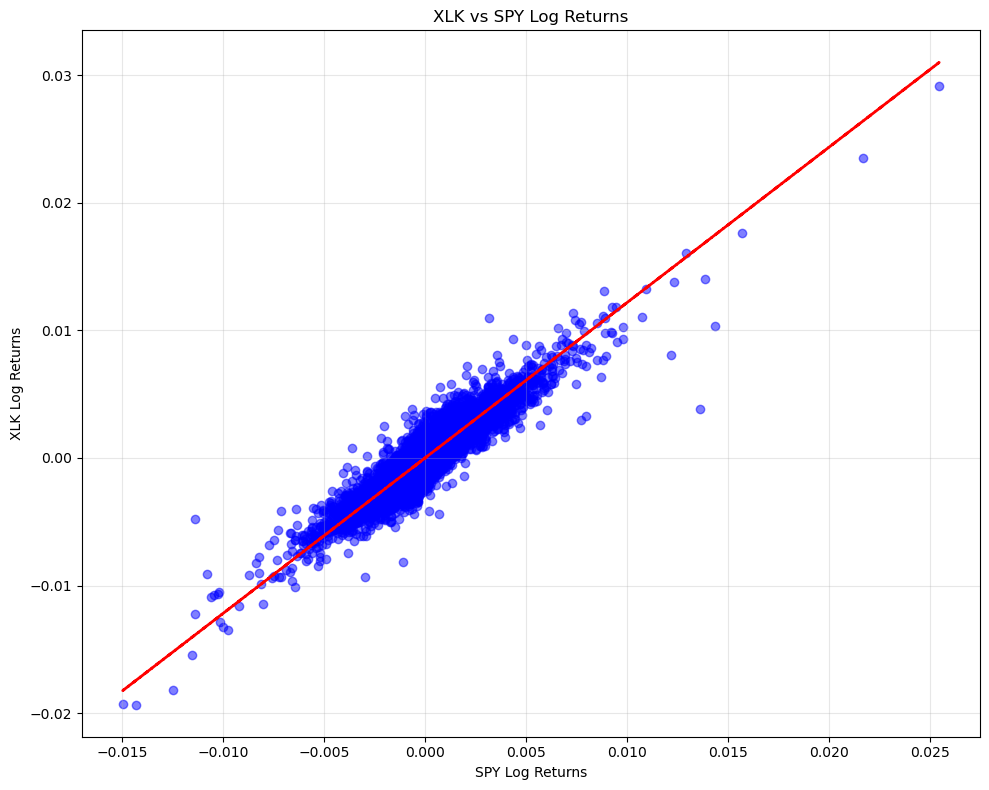

In [27]:
# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(joined_dfs["XLK"]['log_return_mid_spy'], joined_dfs["XLK"]['log_return_mid_xl*'], alpha=0.5, color='blue')

# Add a trend line
z = np.polyfit(joined_dfs["XLK"]['log_return_mid_spy'], joined_dfs["XLK"]['log_return_mid_xl*'], 1)
p = np.poly1d(z)
plt.plot(joined_dfs["XLK"]['log_return_mid_spy'], p(joined_dfs["XLK"]['log_return_mid_spy']), 'r--', linewidth=2)

# Add labels, title, and grid
plt.xlabel('SPY Log Returns')
plt.ylabel('XLK Log Returns')
plt.title('XLK vs SPY Log Returns')
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

### 2.4 Calculate Daily Betas

Now we can use the returns for pairs of equities to calculate the Beta for each trading date.

Here the Betas are calculated for XLK/SPY:

In [28]:
# Define column names x and y for the Beta calculation
x = "log_return_mid_spy"
y = "log_return_mid_xl*"

# Calculate Betas for each day and convert to a dataframe, for each sector ETF against SPY
beta_dfs = {}
print(f"Calculating daily Betas against SPY ...")
for ticker, df in joined_dfs.items():
    print(f"{ticker:<4} ...", end=" ")
    tmp = df[["date", x, y]]
    num = (tmp[x] * tmp[y]).groupby(tmp["date"]).sum()
    den = (tmp[x] ** 2).groupby(tmp["date"]).sum()
    beta = num / den.replace(0, np.nan)
    beta_dfs[ticker] = beta.to_frame("xl*_spy_beta")
    print("Done")
print("Done")

# Show the results for XLK as an example
beta_dfs["XLK"]

Calculating daily Betas against SPY ...
XLB  ... Done
XLC  ... Done
XLE  ... Done
XLF  ... Done
XLI  ... Done
XLK  ... Done
XLP  ... Done
XLRE ... Done
XLU  ... Done
XLV  ... Done
XLY  ... Done
Done


,xl*_spy_beta
date,
2018-07-02,1.109645
2018-07-03,1.219494
2018-07-05,1.075978
2018-07-06,1.079112
2018-07-09,1.225060
...,...
2026-03-09,1.340390
2026-03-10,1.363675
2026-03-11,1.357485


### 2.5 Save/Reload Daily Betas

At this point we'll save the daily Betas to .csv files so they can be reloaded without running all the previous steps:<br>
**(This step can be skipped in subsequent passes)**

In [29]:
# Create a template for building the .csv file paths from the ticker symbols
file_template = "Data/Capstone 02/02.01 Processed/Daily Betas {ticker}-SPY.csv"

# Write .csv files with the daily Betas
print("Writing CSV files with daily Betas ...")
for ticker in beta_dfs:
    print(f"{ticker:<4} ...", end=" ")
    beta_dfs[ticker].to_csv(file_template.format(ticker=ticker))
    print("Done")
print("Done")

Writing CSV files with daily Betas ...
XLB  ... Done
XLC  ... Done
XLE  ... Done
XLF  ... Done
XLI  ... Done
XLK  ... Done
XLP  ... Done
XLRE ... Done
XLU  ... Done
XLV  ... Done
XLY  ... Done
Done


**RESTART HERE:** From this cell we can reload the daily Betas from the .csv files without running all the previous steps (after running the import code cell at the top):

In [30]:
# Redefine the 12 ETF ticker symbols in case we're restarting from here
tickers = ["SPY", "XLB", "XLC", "XLE", "XLF", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"]

# Create a template for building the .csv file paths from the ticker symbols
file_template = "Data/Capstone 02/02.01 Processed/Daily Betas {ticker}-SPY.csv"

# Reload the daily Betas from .csv files
beta_dfs = {}
print("Loading daily Betas from CSV files ...")
for ticker in tickers:
    if ticker != "SPY":
        print(f"{ticker:<4} ...", end=" ")
        beta_dfs[ticker] = pd.read_csv(file_template.format(ticker=ticker), index_col=0)        
        print("Done")
print("Done")

Loading daily Betas from CSV files ...
XLB  ... Done
XLC  ... Done
XLE  ... Done
XLF  ... Done
XLI  ... Done
XLK  ... Done
XLP  ... Done
XLRE ... Done
XLU  ... Done
XLV  ... Done
XLY  ... Done
Done


## 3 Data Analysis
Now let's take a look at the characteristics of the daily Betas for each of the sector ETFs against SPY.

### 3.1 Histograms

As a first step, let's examine histograms of the Betas, for all 11 sector ETFs against SPY:

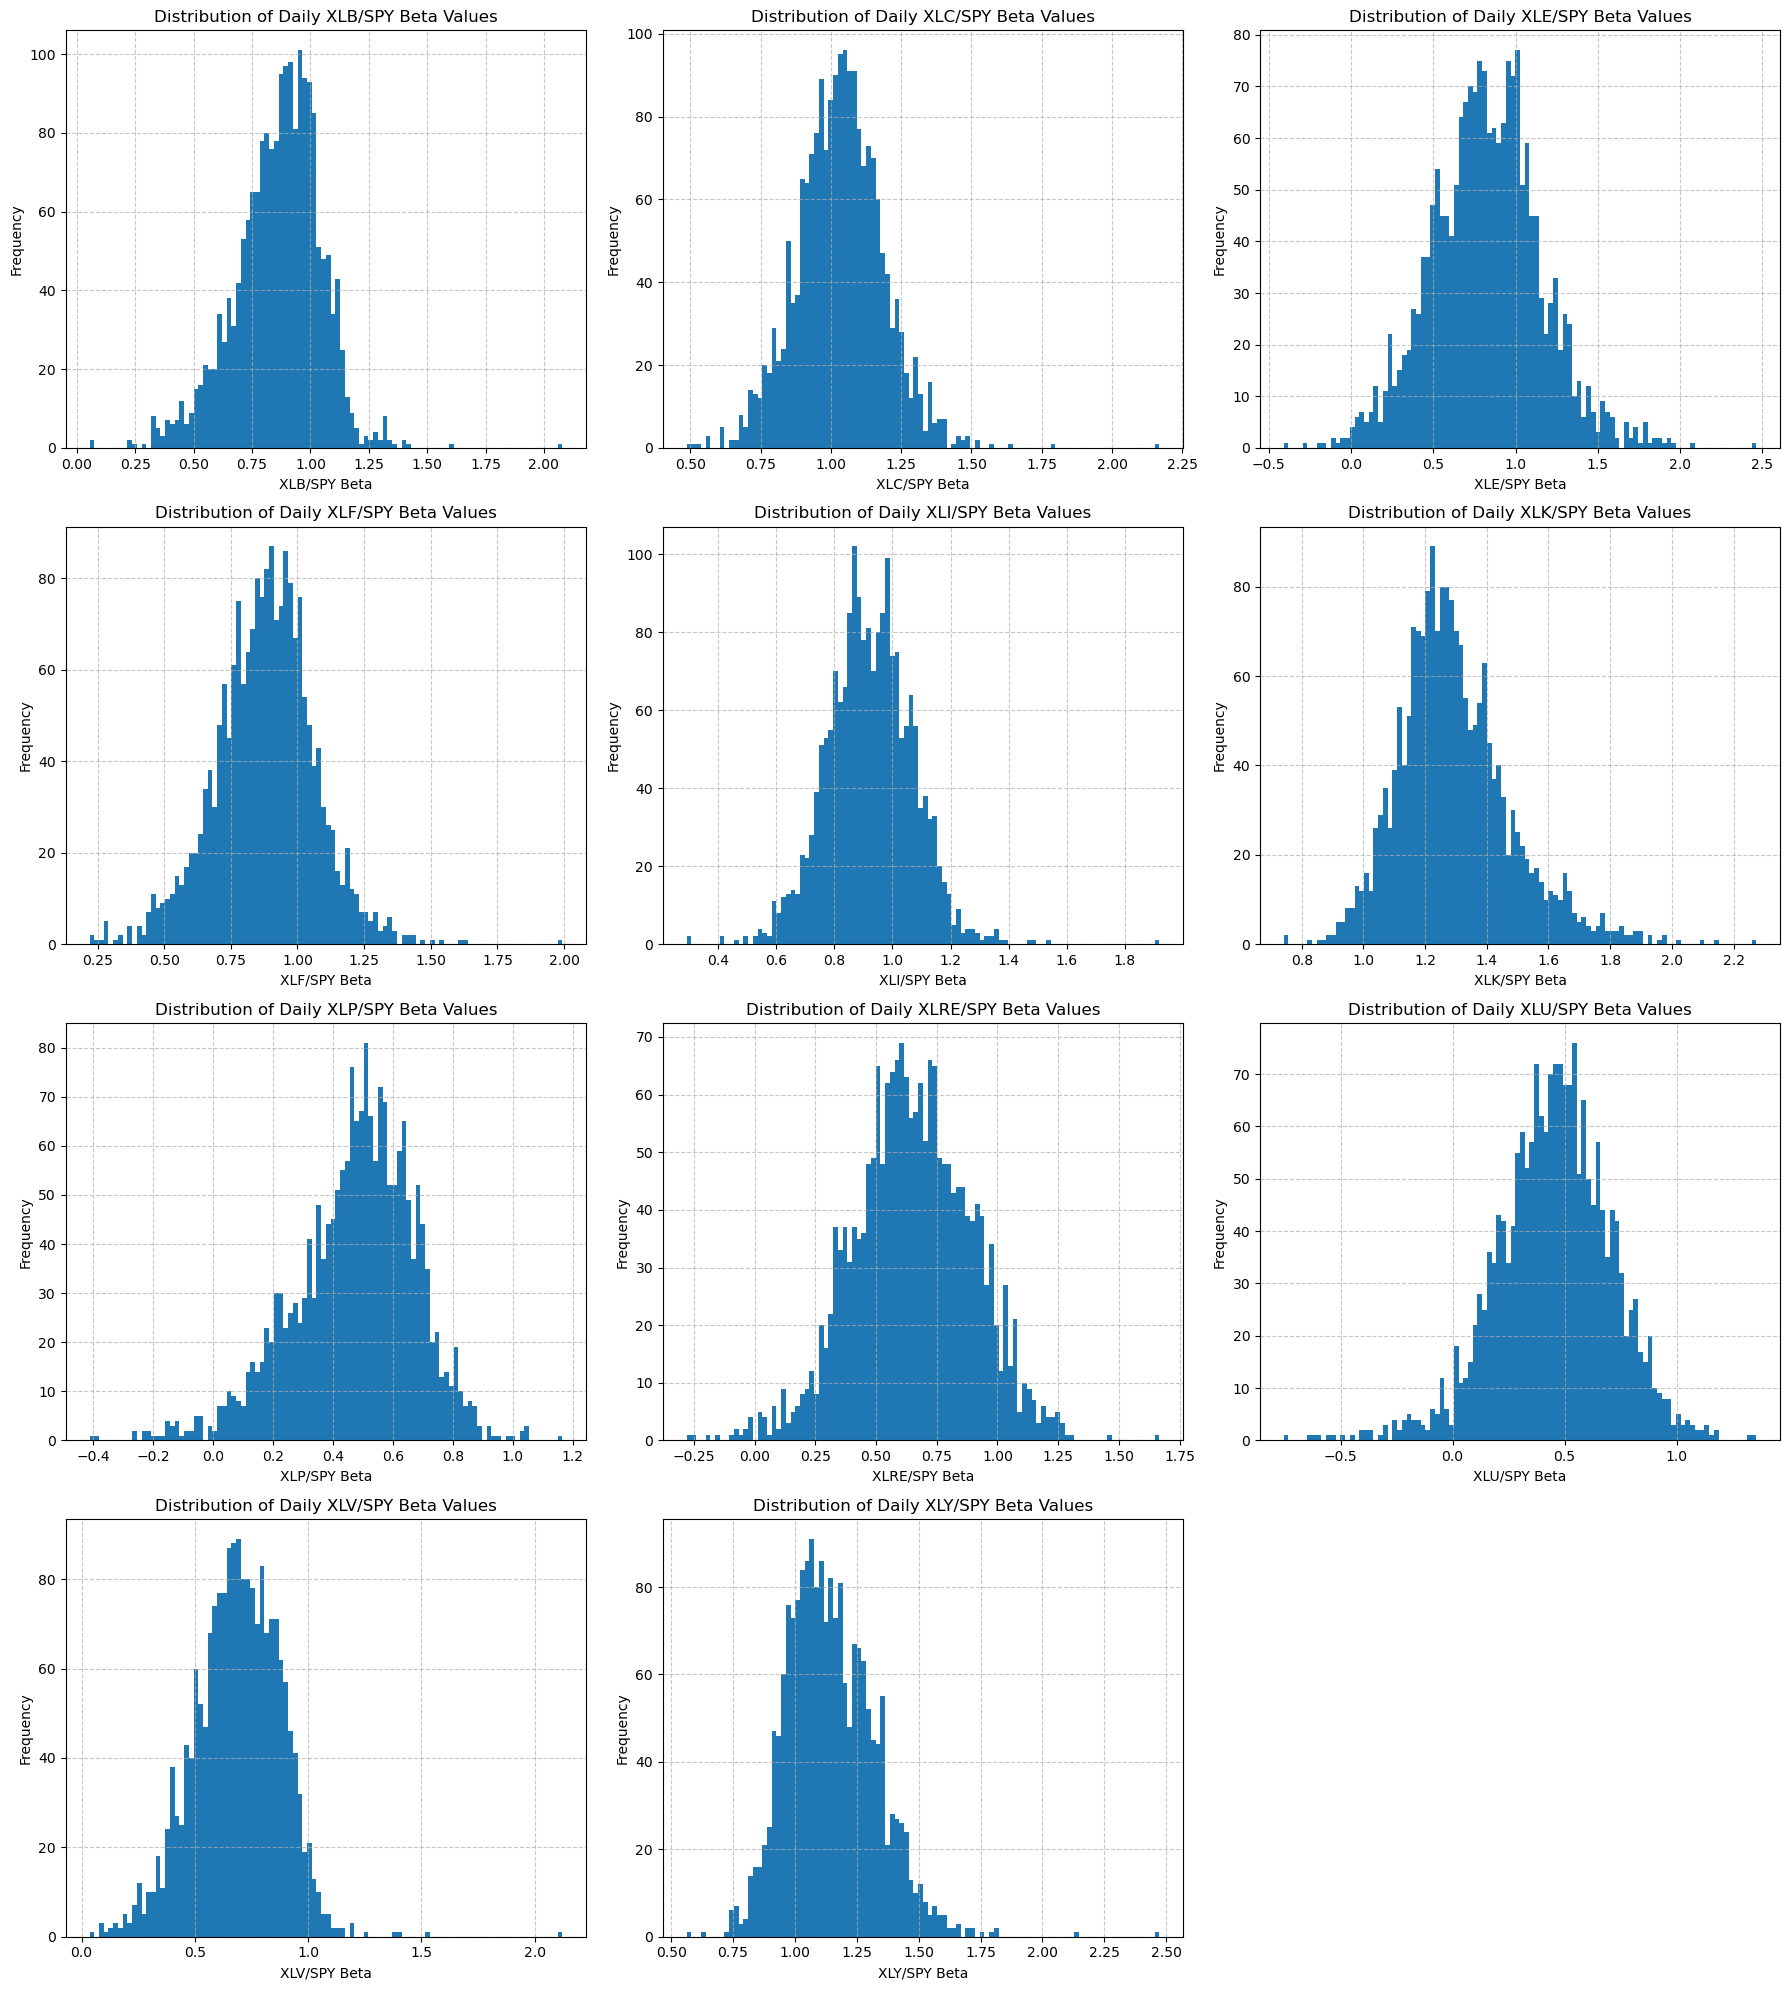

In [31]:
# Create a 4 x 3 grid of subplots
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

# Loop over the 11 sector ETFs and plot each histogram
for ax, (ticker, df_beta) in zip(axes, beta_dfs.items()):
    ax.hist(df_beta['xl*_spy_beta'], bins=100, alpha=1.0, linewidth=1.0)
    ax.set_xlabel(f'{ticker}/SPY Beta')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of Daily {ticker}/SPY Beta Values')
    ax.grid(True, alpha=0.7, linestyle='--')

# Hide the unused subplot at the bottom
axes[-1].set_visible(False)

# Show the plot
plt.tight_layout()
plt.show()

There are some interesting features in these histograms. Note first that the outliers look reasonable, which is a good check on the validity of this data. There also seems to be varying skew in the distributions, with some sectors (e.g. XLB, XLP) having negative skew, and others (e.g. XLK, XLY) having positive skew. The means also vary quite a bit, with some means well below 1.0 (e.g. XLP, XLRE, XLU, XLV) and others clearly above 1.0 (e.g. XLK). While these features are interesting, futher investigation of these differences is beyond the scope of the current project.

### 3.2 Time Series Line Plots

Let's also look at plots of each Beta time series:

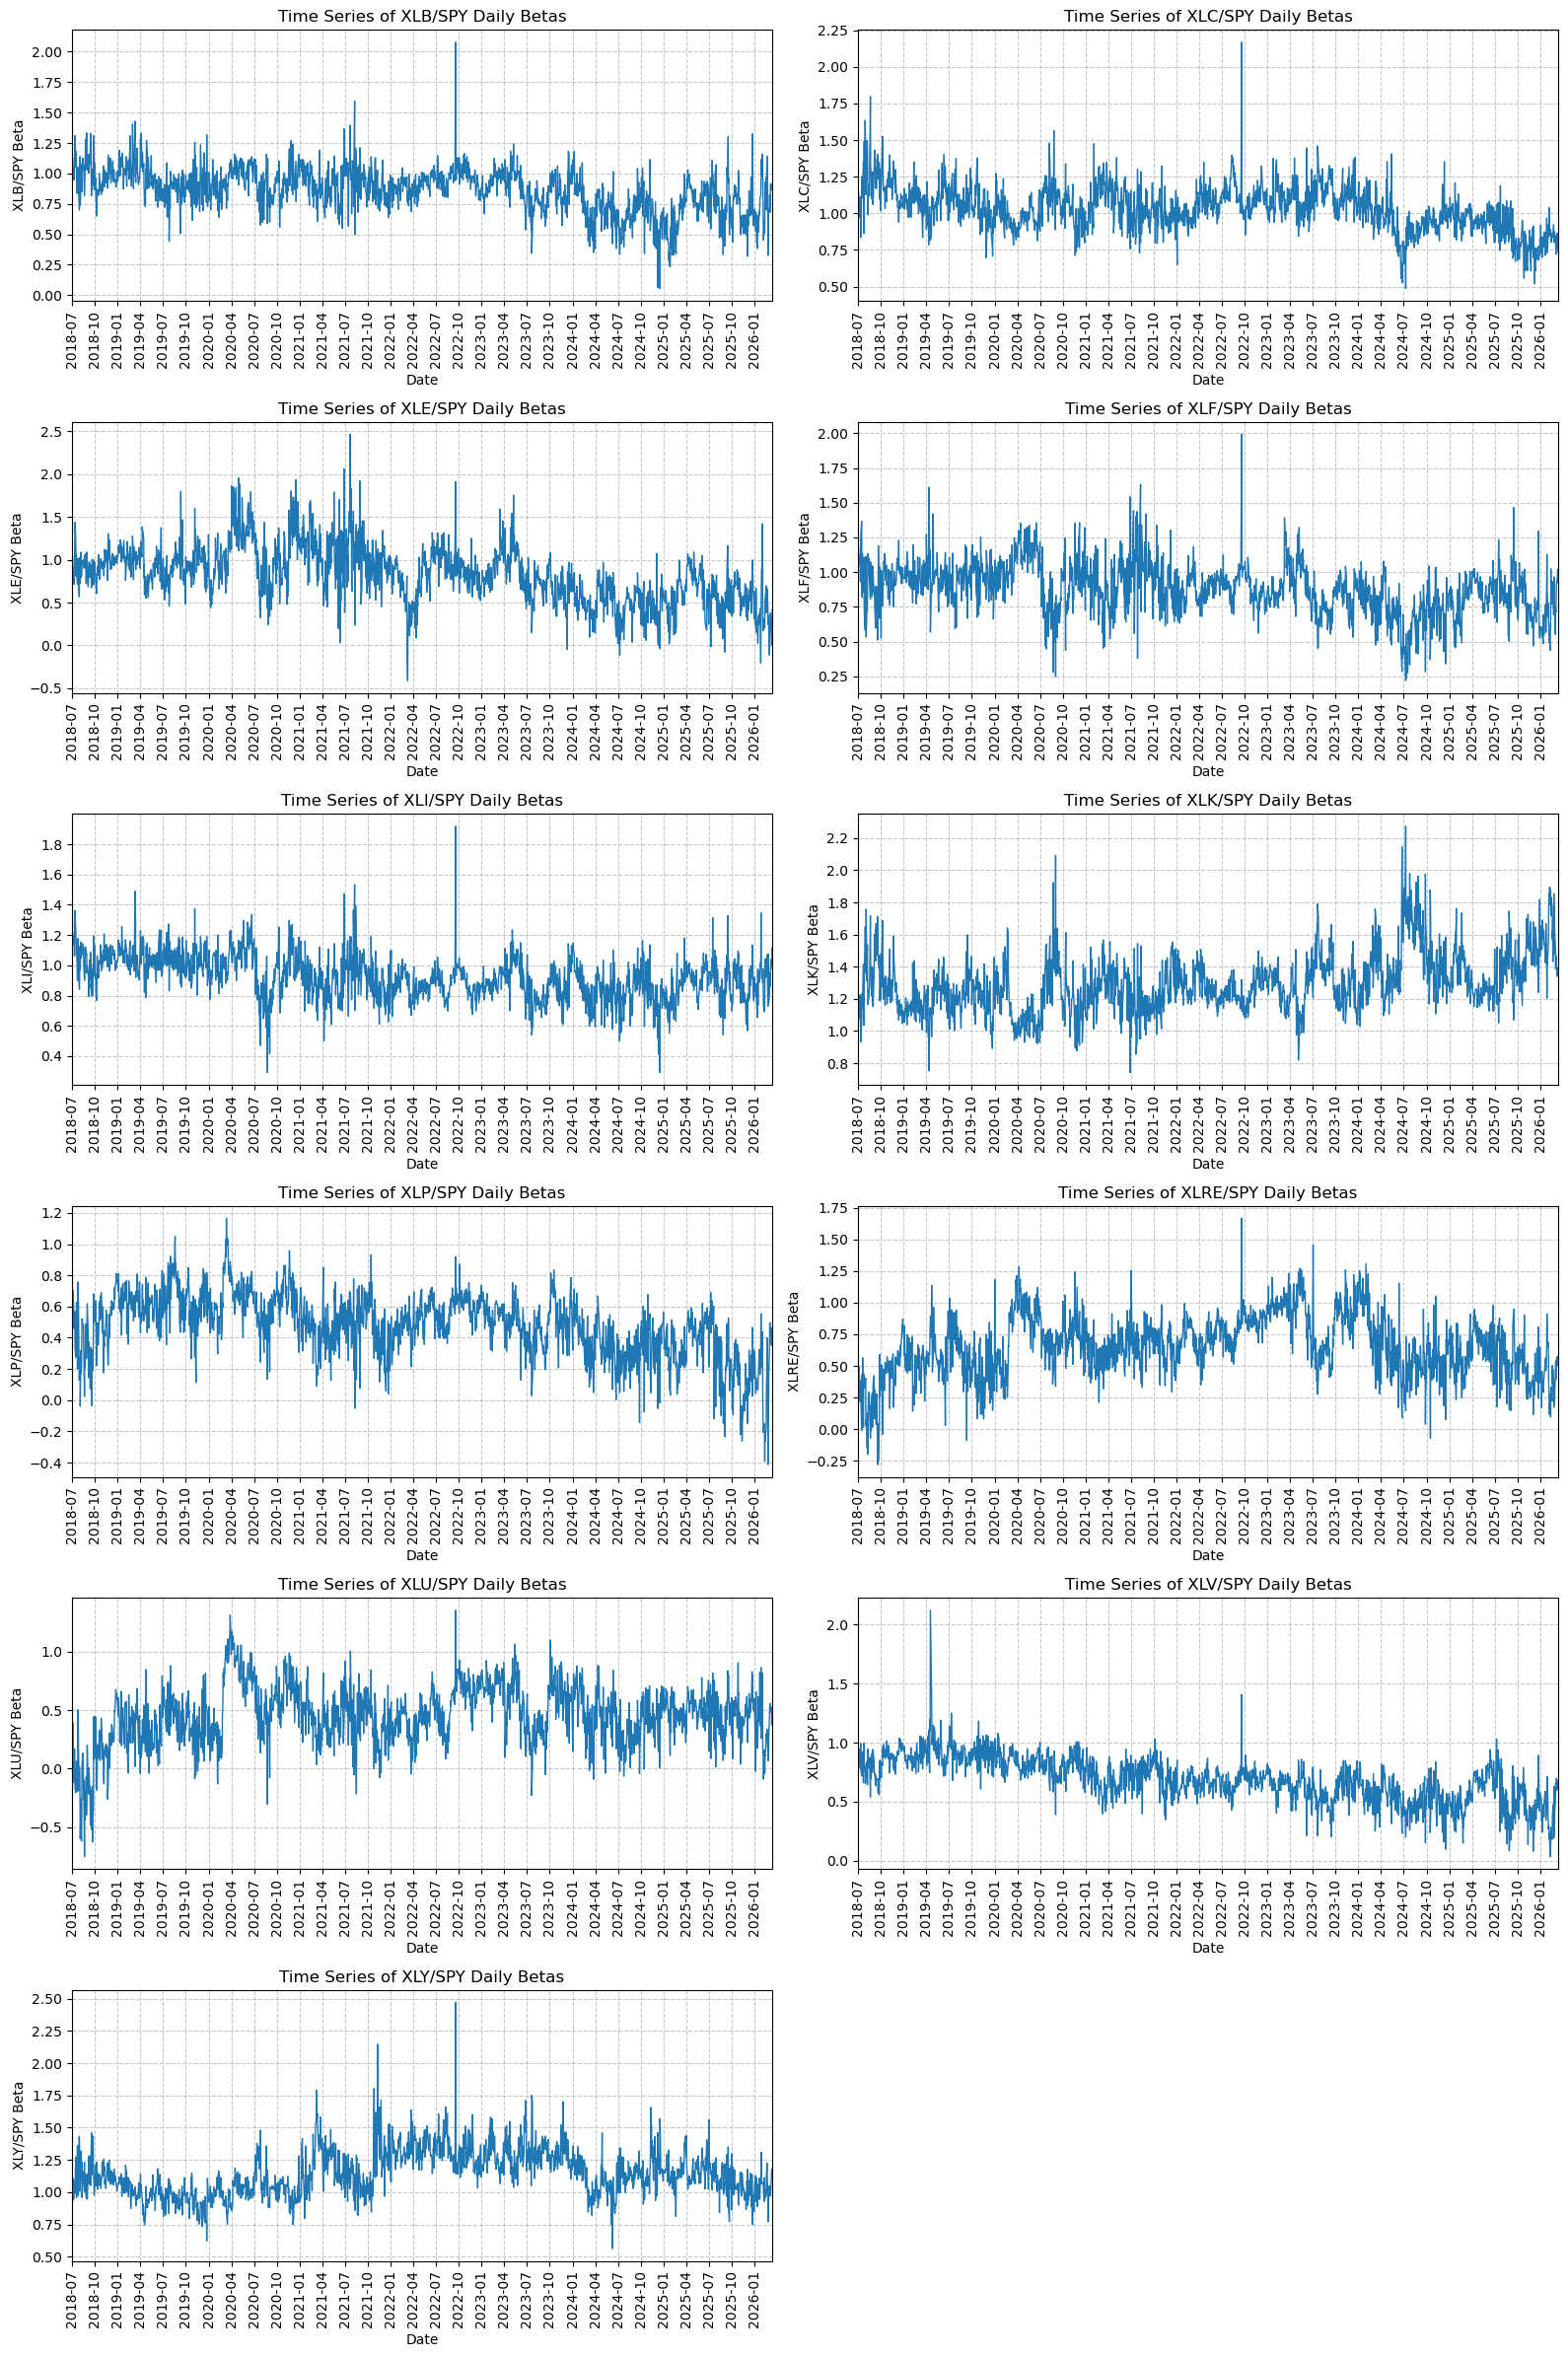

In [32]:
# Create a 6 x 2 grid of subplots
fig, axes = plt.subplots(6, 2, figsize=(16, 24))
axes = axes.flatten()

# Loop over the 11 sector ETFs and plot each time series
for ax, (ticker, df_beta) in zip(axes, beta_dfs.items()):

    # Fix the index so the dates plot correctly
    df_plot = df_beta.copy()
    df_plot.index = pd.to_datetime(df_plot.index)

    # Plot the time series
    ax.plot(df_plot.index, df_plot['xl*_spy_beta'], linewidth=1, alpha=1.0)
    ax.set_xlabel('Date')
    ax.set_ylabel(f'{ticker}/SPY Beta')
    ax.set_title(f'Time Series of {ticker}/SPY Daily Betas')
    ax.grid(True, alpha=0.7, linestyle='--')

    # Format the X axis to show the dates every 3 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.set_xlim(pd.Timestamp('2018-07-01'), df_plot.index.max())
    ax.tick_params(axis='x', rotation=90)

# Hide the unused subplot at the bottom
axes[-1].set_visible(False)

# Show the plot
plt.tight_layout()
plt.show()

These time series plots appear to show overall trends in the movements of Betas over time, although a closer look with ACF plots will be required to determine if this is true. There also seems to be quite a bit of variation between the differt sectors in terms of how the Betas are changing, with some drifting downward in recent months and years (e.g. XLC and XLV), while others have drifted upward recently (e.g. XLK). Also note that while there appear to be occasional outliers, especially on the positive end, none of these exceed a Beta of 2.5, so I will treat these as valid data points, given that shocks to specific sectores do occur when significant news arrives suddenly.

### 3.3 Time Series ACF Plots

Now let's look at the Autocorrelation Function (ACF) plots of the Betas and Beta differences, starting with the Betas:

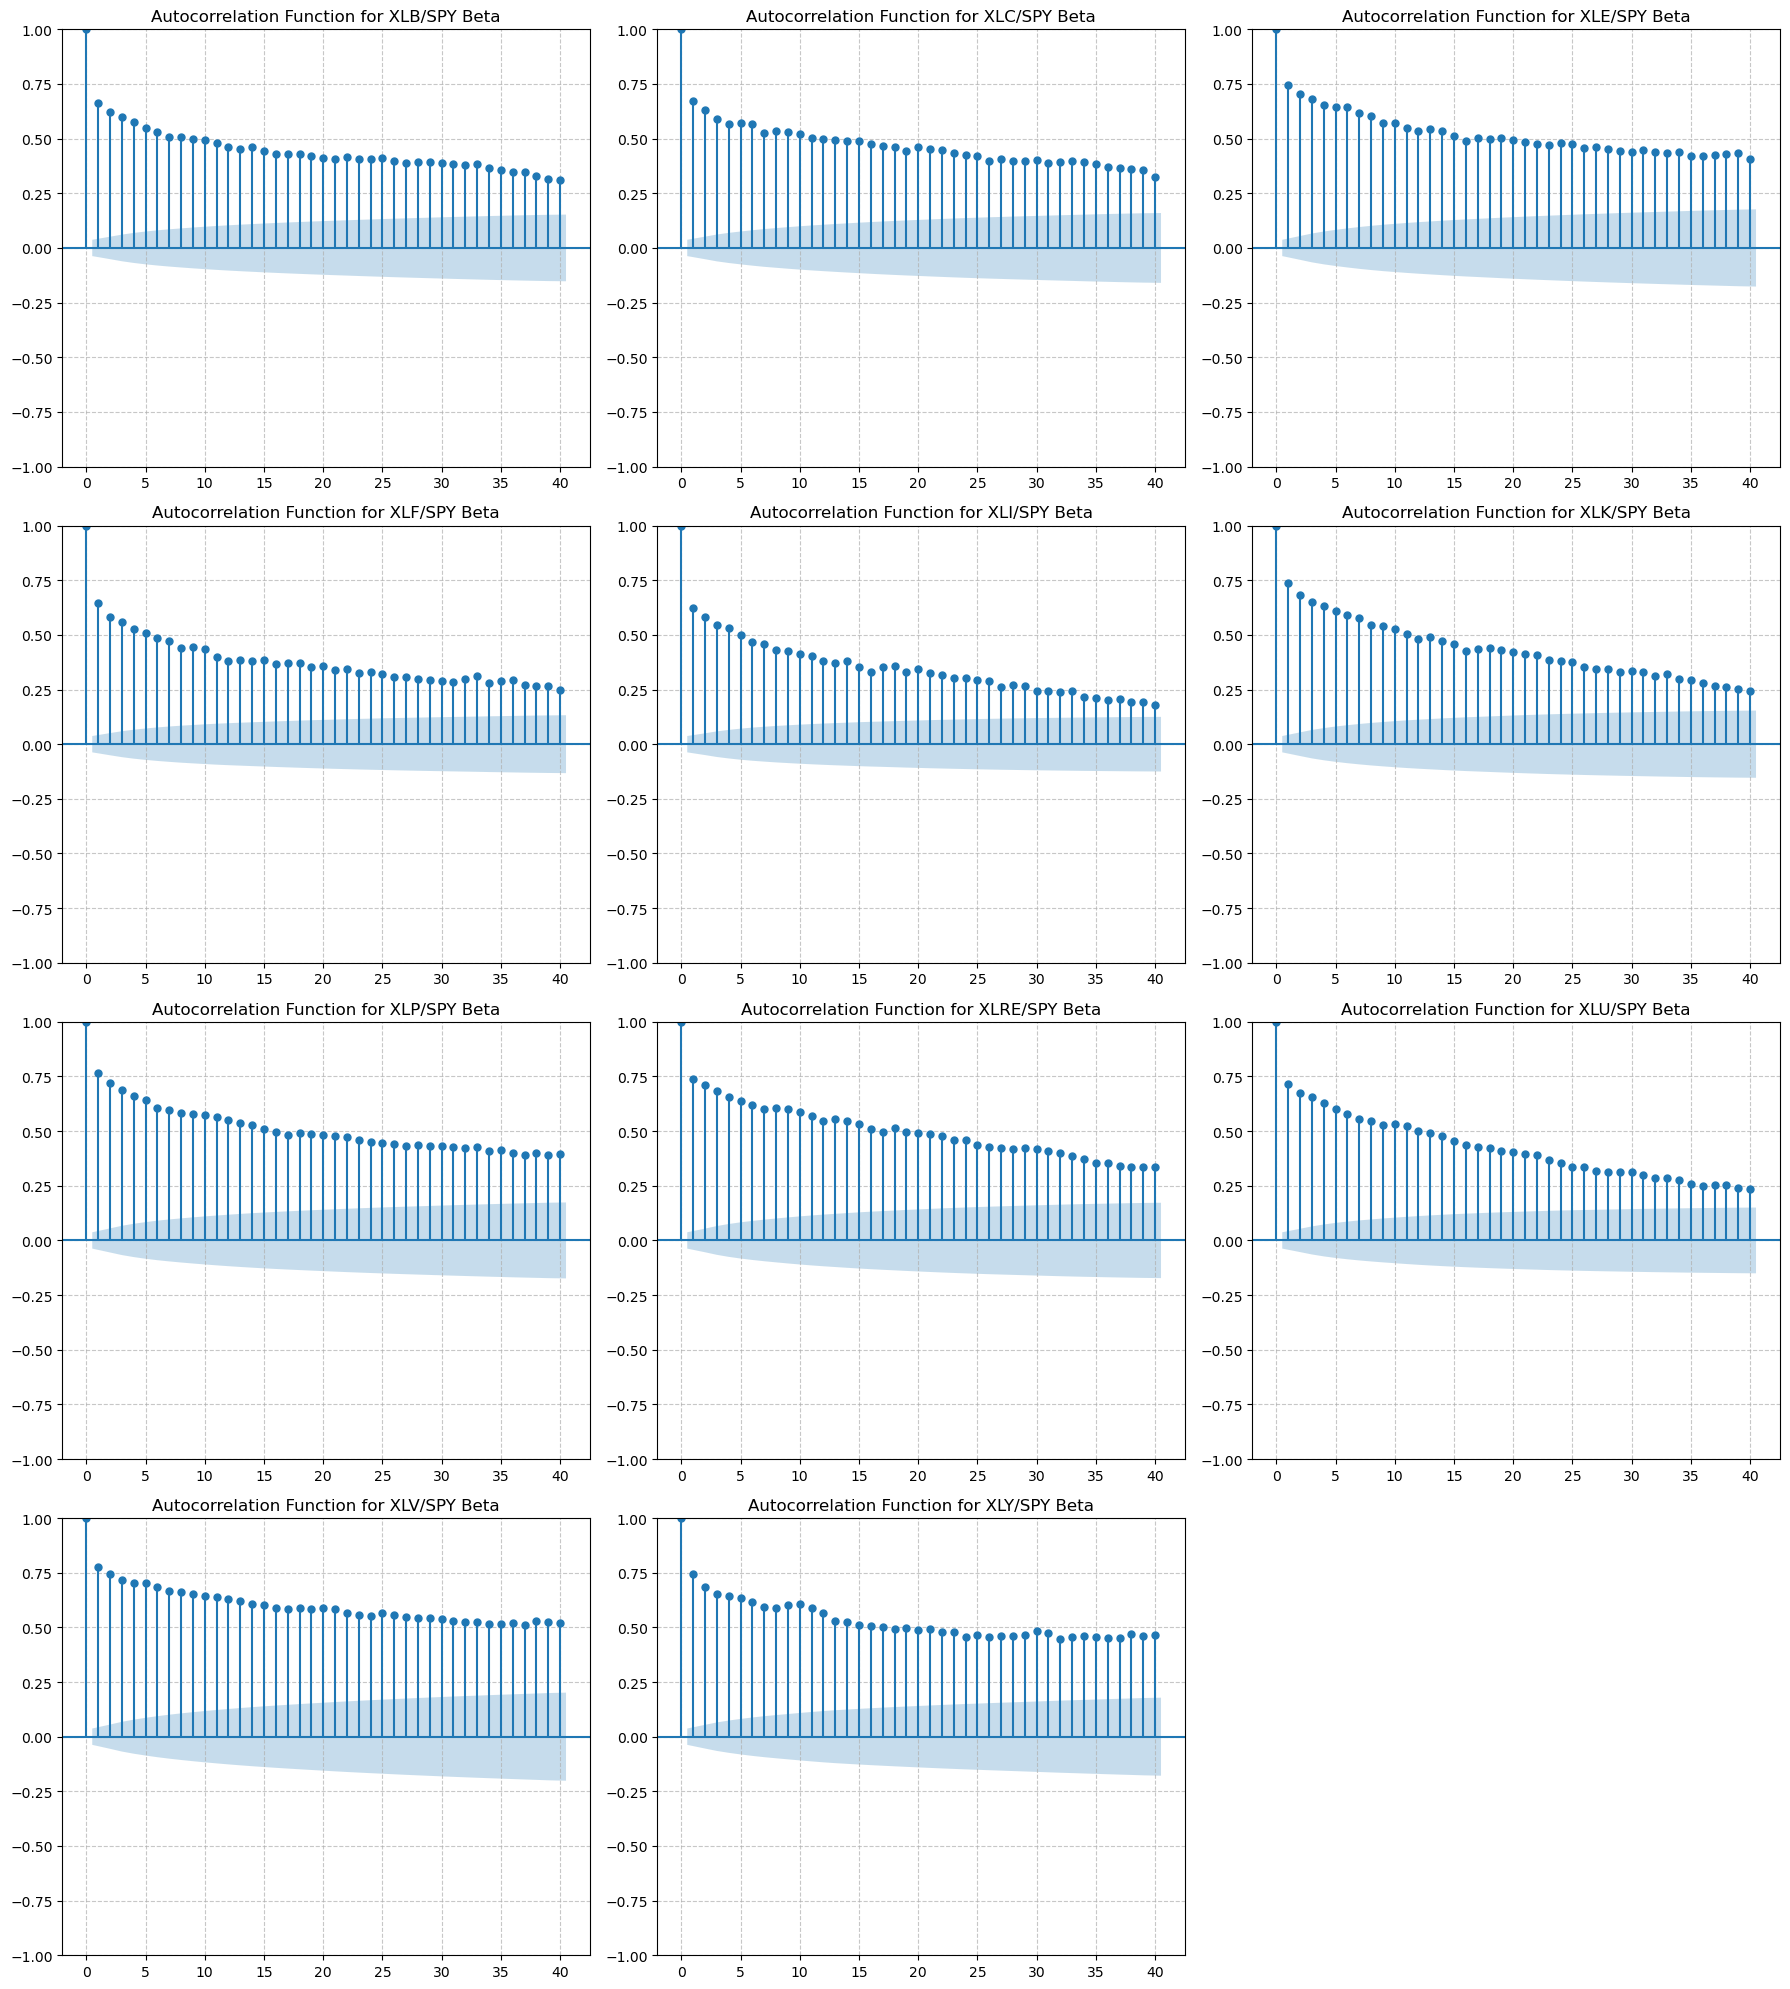

In [33]:
# Create a 4 x 3 grid of subplots
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

# Loop over the 11 sector ETFs and plot each autocorrelation function
for ax, (ticker, df_beta) in zip(axes, beta_dfs.items()):
    plot_acf(df_beta['xl*_spy_beta'], lags=40, alpha=0.10, title=f'Autocorrelation Function for {ticker}/SPY Beta', ax=ax)
    ax.grid(True, linestyle='--', alpha=0.7)

# Hide the unused subplot at the bottom
axes[-1].set_visible(False)

# Show the plot
plt.tight_layout()
plt.show()

Not surpisingly, all the plots show strong positive correlations with lagged Betas, which shows that there is persistence in the time series of Betas. What's more important, however, is whether or not we see autocorrelations in the differences between lagged Betas, which would be evidence that upward and downward trends are persistent. So next we will plot these:

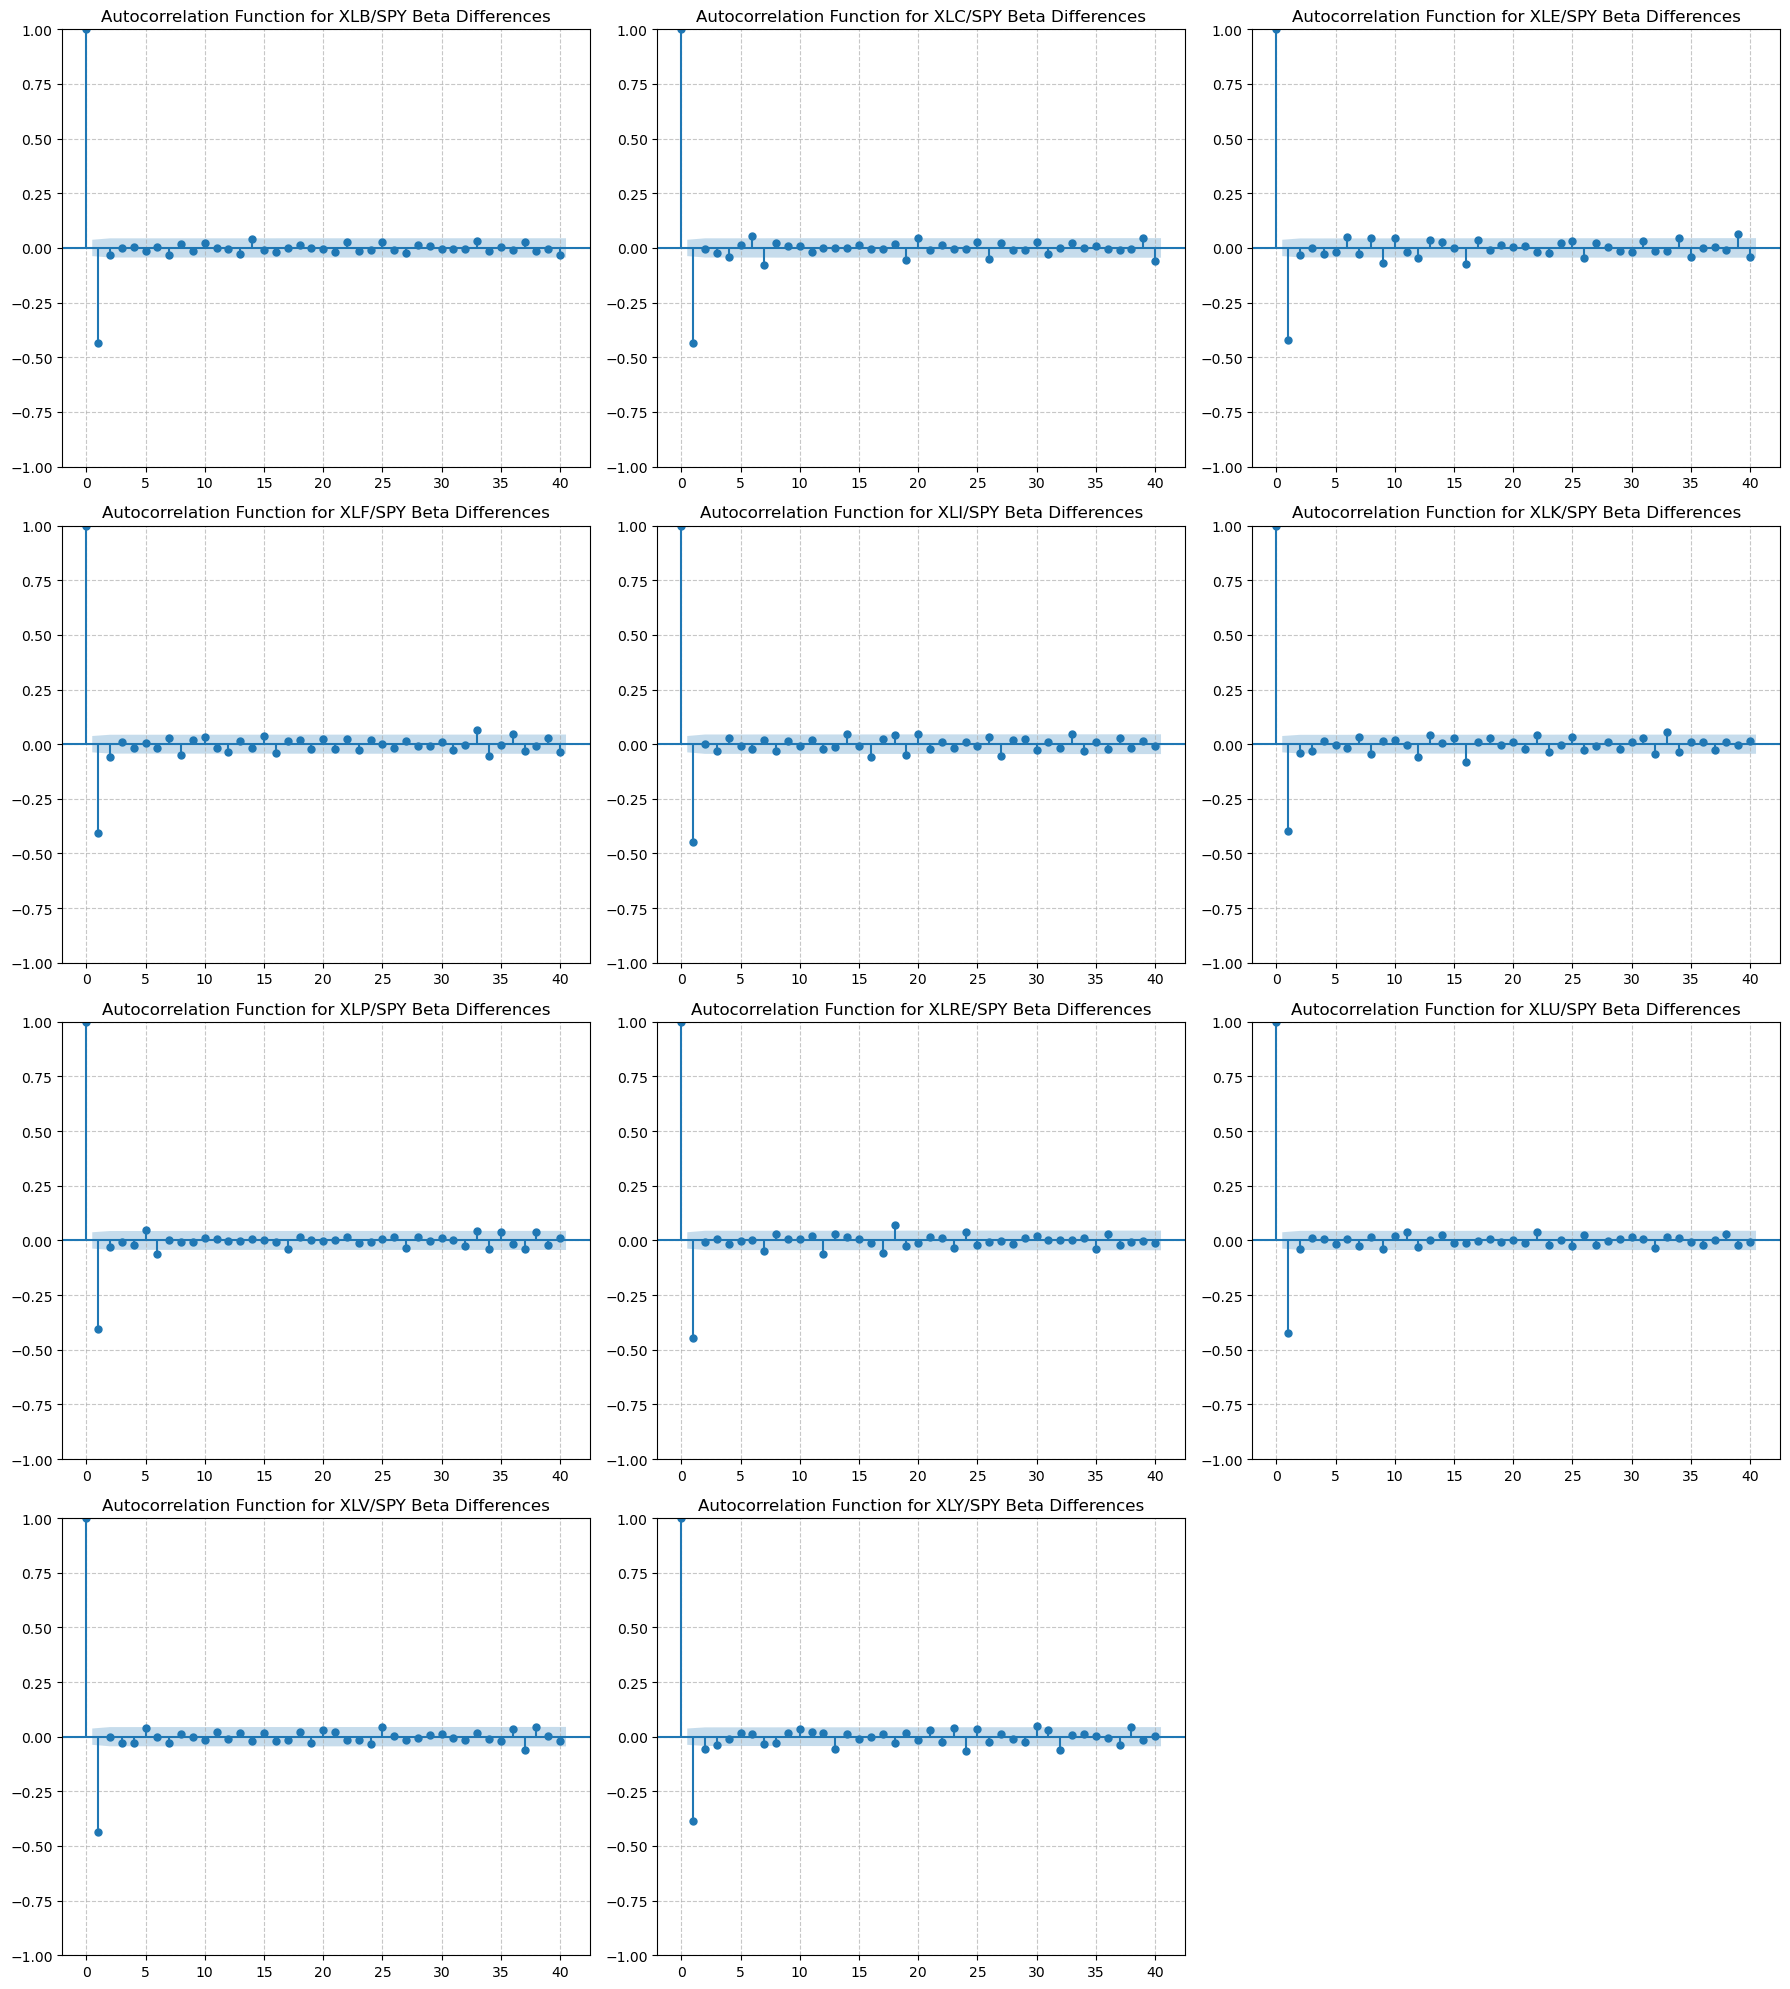

In [34]:
# Create a 4 x 3 grid of subplots
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

# Loop over the 11 sector ETFs and plot each autocorrelation of differences
for ax, (ticker, df_beta) in zip(axes, beta_dfs.items()):
    plot_acf(df_beta['xl*_spy_beta'].diff().dropna(), lags=40, alpha=0.10, title=f'Autocorrelation Function for {ticker}/SPY Beta Differences', ax=ax)
    ax.grid(True, linestyle='--', alpha=0.7)

# Hide the unused subplot at the bottom
axes[-1].set_visible(False)

# Show the plot
plt.tight_layout()
plt.show()

### 3.4 Conclusion

With the daily changes in Betas we see a completely different story. From the line plots of the time series, it looked like there might be upward and downward trends in the data. However the ACF plots for differences show only negative correlations with the previous day's changes in Beta (which is expected due to the "bounce back" that is expected after a Beta deviates from the mean), but no correlation with differences at greater lags. This indicates that there are not significant upward or downward trends in the way Beta moves over time, other than an overall reversion toward the mean. In other words, the time series might be a random walk with mean reversion. Therefore the challenge will be to see if we can do a better job of predicting Beta than just using the previous day's value.

## 4 Prediction Modeling
Now we will try to develop models to predict future Betas from past data. We'll use linear regression because we are trying to predict a continuous numerical value, the next day’s Beta, from previous Beta values using a simple linear relationship. We'll use mean squared error as our evaluation metric because it measures how far the predicted Betas are from the actual Betas, while penalizing larger errors more heavily.

### 4.1 Creation of Input Features (X) and Output Target (y)

We are going to focus on regression models that only look at previous days' Betas for the prediction of the next day's Beta. We won't look any further back than 20 trading days for these models, so we will start by building X and y data sets for each ETF/SPY pair, where X has 20 columns representing the Betas on days -20 through -1, and y is the Beta for day 0.

In [35]:
# Set the window size for this feature extraction
window_size = 20

# Set the names of the lagged columns for X
col_names = [f"lag_{k}" for k in range(window_size, 0, -1)]

# For each ETF/SPY pair, create data sets for features (X) and target (y) using a rolling window
X_dfs = {}
y_series = {}
for ticker, df_beta in beta_dfs.items():
    data = df_beta["xl*_spy_beta"].to_numpy()
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])

    # Convert X to a DataFrame and y to a Series
    X_dfs[ticker] = pd.DataFrame(X, columns=col_names, index=df_beta.index[window_size:])
    y_series[ticker] = pd.Series(y, index=X_dfs[ticker].index, name="target")

Let's inspect this data for XLK/SPY as an example:

In [36]:
print("X shape for XLK/SPY:", X_dfs["XLK"].shape)
print("y shape for XLK/SPY:", y_series["XLK"].shape)
print()
X_dfs["XLK"]

X shape for XLK/SPY: (1915, 20)
y shape for XLK/SPY: (1915,)



,lag_20,lag_19,lag_18,lag_17,lag_16,lag_15,lag_14,lag_13,lag_12,lag_11,lag_10,lag_9,lag_8,lag_7,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1
date,,,,,,,,,,,,,,,,,,,,
2018-07-31,1.109645,1.219494,1.075978,1.079112,1.225060,1.143174,1.214554,0.932691,0.948056,1.065723,1.175560,1.233829,1.140365,1.220741,1.415061,1.250221,1.035195,1.269439,1.373814,1.646936
2018-08-01,1.219494,1.075978,1.079112,1.225060,1.143174,1.214554,0.932691,0.948056,1.065723,1.175560,1.233829,1.140365,1.220741,1.415061,1.250221,1.035195,1.269439,1.373814,1.646936,1.625517
2018-08-02,1.075978,1.079112,1.225060,1.143174,1.214554,0.932691,0.948056,1.065723,1.175560,1.233829,1.140365,1.220741,1.415061,1.250221,1.035195,1.269439,1.373814,1.646936,1.625517,1.524204
2018-08-03,1.079112,1.225060,1.143174,1.214554,0.932691,0.948056,1.065723,1.175560,1.233829,1.140365,1.220741,1.415061,1.250221,1.035195,1.269439,1.373814,1.646936,1.625517,1.524204,1.360893
2018-08-06,1.225060,1.143174,1.214554,0.932691,0.948056,1.065723,1.175560,1.233829,1.140365,1.220741,1.415061,1.250221,1.035195,1.269439,1.373814,1.646936,1.625517,1.524204,1.360893,1.757903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09,1.894553,1.892797,1.811385,1.871708,1.719244,1.830862,1.769783,1.572327,1.625684,1.431410,1.649570,1.853693,1.477308,1.770845,1.619248,1.521395,1.385507,1.448205,1.467126,1.406153
2026-03-10,1.892797,1.811385,1.871708,1.719244,1.830862,1.769783,1.572327,1.625684,1.431410,1.649570,1.853693,1.477308,1.770845,1.619248,1.521395,1.385507,1.448205,1.467126,1.406153,1.340390
2026-03-11,1.811385,1.871708,1.719244,1.830862,1.769783,1.572327,1.625684,1.431410,1.649570,1.853693,1.477308,1.770845,1.619248,1.521395,1.385507,1.448205,1.467126,1.406153,1.340390,1.363675


In [37]:
y_series["XLK"]

date
2018-07-31    1.625517
2018-08-01    1.524204
2018-08-02    1.360893
2018-08-03    1.757903
2018-08-06    1.310512
                ...   
2026-03-09    1.340390
2026-03-10    1.363675
2026-03-11    1.357485
2026-03-12    1.393756
2026-03-13    1.384730
Name: target, Length: 1915, dtype: float64

### 4.2 Train/Dev/Test Split

Now we need to split the data into training, development (validation), and test sets, for each ETF/SPY pair. There are a total of 1,915 dates in each of the data sets.

Because we are dealing with time series data with lagged input features, we can't shuffle the data without creating data leakage from the test and development sets into the training set. We also can't use K-fold cross-validation because then some of the folds would be training on future data that should not have been seen yet when the model is validated on data in the middle of the time series. There are a few techniques to get around these problems, such as using a rolling window for multiple train and validation sets, but for this project we'll get around the issue by just using the first 1,200 dates for the training set, the next 400 dates for the development set, and the final 315 dates for the final test set.

In [38]:
# Define split sizes
n_train = 1200
n_dev   =  400
n_test  =  315

# Create dictionaries to hold the splits
X_train_dfs = {}
X_dev_dfs   = {}
X_test_dfs  = {}

y_train_series = {}
y_dev_series   = {}
y_test_series  = {}

# Split each ETF/SPY pair's X and y data into train/dev/test sets
for ticker in X_dfs:
    X = X_dfs[ticker]
    y = y_series[ticker]

    X_train_dfs[ticker] = X.iloc[:n_train].copy()
    X_dev_dfs[ticker]   = X.iloc[n_train:n_train + n_dev].copy()
    X_test_dfs[ticker]  = X.iloc[n_train + n_dev:n_train + n_dev + n_test].copy()

    y_train_series[ticker] = y.iloc[:n_train].copy()
    y_dev_series[ticker]   = y.iloc[n_train:n_train + n_dev].copy()
    y_test_series[ticker]  = y.iloc[n_train + n_dev:n_train + n_dev + n_test].copy()

Let's confirm that the split was done correctly, by looking at the XLK/SPY sets as an example:

In [39]:
# Confirm the results of the split for XLK/SPY as an example
print("X_train shape for XLK/SPY: ", X_train_dfs["XLK"].shape)
print("X_dev   shape for XLK/SPY: ", X_dev_dfs["XLK"].shape)
print("X_test  shape for XLK/SPY: ", X_test_dfs["XLK"].shape)
print()
print("y_train shape for XLK/SPY: ", y_train_series["XLK"].shape)
print("y_dev   shape for XLK/SPY: ", y_dev_series["XLK"].shape)
print("y_test  shape for XLK/SPY: ", y_test_series["XLK"].shape)

X_train shape for XLK/SPY:  (1200, 20)
X_dev   shape for XLK/SPY:  (400, 20)
X_test  shape for XLK/SPY:  (315, 20)

y_train shape for XLK/SPY:  (1200,)
y_dev   shape for XLK/SPY:  (400,)
y_test  shape for XLK/SPY:  (315,)


### 4.3 Baseline Models

Before fitting our first prediction models, let's calculate baseline test scores on the validation (development) set for each ETF/SPY pair, using two dummy models, one that predicts that each day's Beta will be the average of all the Betas in the training set, and one that predicts that each day's Beta will be equal to the previous day's Beta. We will use mean squared error to evaluate model performances, as explained above.

We'll start with the model that predicts the mean Beta for each ETF/SPY pair:

In [40]:
# For each ETF/SPY pair, calculate the baseline MSE on the validation set for a model that predicts the mean of all the Betas in the training set
print("Validation set MSEs for dummy models that predict mean Beta:")
mses_dummy_mean = {}
for ticker in X_train_dfs:
    dummy_mean = DummyRegressor(strategy="mean").fit(X_train_dfs[ticker], y_train_series[ticker])
    mses_dummy_mean[ticker] = mean_squared_error(y_dev_series[ticker], dummy_mean.predict(X_dev_dfs[ticker]))
    print(f"{ticker:<4}: {mses_dummy_mean[ticker]:.6f}")

Validation set MSEs for dummy models that predict mean Beta:
XLB : 0.060985
XLC : 0.026287
XLE : 0.203813
XLF : 0.064564
XLI : 0.029139
XLK : 0.070751
XLP : 0.050145
XLRE: 0.070079
XLU : 0.051854
XLV : 0.065315
XLY : 0.028626


Next we'll calculate MSEs for models that predict the previous day's Beta for each ETF/SPY pair:

In [41]:
# For each ETF/SPY pair, calculate the baseline MSE on the validation set for a model that predicts that each day's Beta is the same as the last day's Beta
print("Validation set MSEs for dummy models that predict last Beta:")
mses_dummy_last = {}
for ticker in X_train_dfs:
    mses_dummy_last[ticker] = mean_squared_error(y_dev_series[ticker], np.asarray(X_dev_dfs[ticker])[:, 19])
    print(f"{ticker:<4}: {mses_dummy_last[ticker]:.6f}")

Validation set MSEs for dummy models that predict last Beta:
XLB : 0.020568
XLC : 0.013305
XLE : 0.041453
XLF : 0.017483
XLI : 0.015993
XLK : 0.021636
XLP : 0.020552
XLRE: 0.039541
XLU : 0.040109
XLV : 0.017832
XLY : 0.017452


The models that predict that each day's Beta is the same as the last is much better (produces a lower MSE) than the models that predict only the mean, so the  latter MSEs will be the baseline scores that we must beat with better models.

### 4.4 Regression Models

Now we can begin developing regression models that use the previous days' Betas to predict the next day's Beta. Because all the values in the training and development sets are using the same scale, we won't need to transform the data with StandardScalar(). We'll just use the values as is.

#### 4.4.1 Models Using All 20 Lagged Betas

Let's start with regression models that use all 20 previous days' Betas to predict the next day's Beta.

In [42]:
# For each ETF/SPY pair, calculate the validation set MSE for a model that uses all 20 previous days' Betas to predict the next day's Beta
print("Validation set MSEs for models that use all 20 lagged Betas:")
models_20 = {}
mses_20   = {}
for ticker in X_train_dfs:

    # Create a linear regression model and fit it with all 20 input features
    models_20[ticker] = LinearRegression().fit(X_train_dfs[ticker], y_train_series[ticker])

    # Calculate the performance on the validation set
    mses_20[ticker] = mean_squared_error(y_dev_series[ticker], models_20[ticker].predict(X_dev_dfs[ticker]))
    print(f"{ticker:<4}: {mses_20[ticker]:.6f}")

Validation set MSEs for models that use all 20 lagged Betas:
XLB : 0.016152
XLC : 0.009717
XLE : 0.029683
XLF : 0.014889
XLI : 0.011444
XLK : 0.017193
XLP : 0.015015
XLRE: 0.027653
XLU : 0.028197
XLV : 0.013138
XLY : 0.012091


Comparing these MSEs to those for the dummy models, we see that the performances are definitely better than those of the baseline models using only the last day, which is a good sign.

Now let's look at the model coefficients for the XLK/SPY model as an example, to see what's going on:

XLK/SPY Model intercept and coefficients for each of the 20 previous days:
Intercept: 0.1665382516953704
Day -20:  0.0229
Day -19:  0.0299
Day -18:  0.0308
Day -17:  0.0147
Day -16: -0.0634
Day -15: -0.0289
Day -14:  0.0278
Day -13:  0.0571
Day -12: -0.0869
Day -11:  0.0287
Day -10:  0.0507
Day  -9:  0.0302
Day  -8: -0.0391
Day  -7:  0.0567
Day  -6:  0.0162
Day  -5:  0.0324
Day  -4:  0.0876
Day  -3:  0.0530
Day  -2:  0.1660
Day  -1:  0.3783


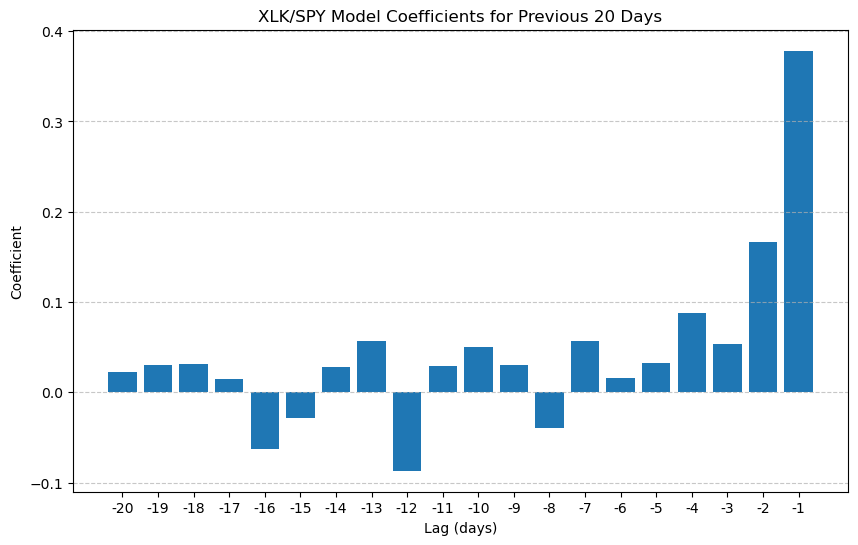

In [43]:
# Get the intercept and the coefficients for the XLK/SPY model
intercept    = models_20["XLK"].intercept_
coefficients = models_20["XLK"].coef_

# Print the intercept and the coefficients
print("XLK/SPY Model intercept and coefficients for each of the 20 previous days:")
print(f"Intercept: {intercept}")
for i, coef in enumerate(coefficients):
    day = -(20 - i)
    print(f"Day {day:>3}: {coef: .4f}")

# Plot the coefficients
plt.figure(figsize=(10, 6))
x = range(1, 21)
plt.bar(x, coefficients)
plt.xlabel('Lag (days)')
plt.ylabel('Coefficient')
plt.title('XLK/SPY Model Coefficients for Previous 20 Days')
plt.xticks(x, range(-20, 0))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The model appears to be calculating a weighted average of the Betas for recent days, plus the intercept term.

The coefficients look pretty noisy for lags greater than about 5 days, and for lags greater than 10 days it's not clear that these features add any predictive power.

#### 4.4.2 Models Using Between 1 and 20 Lagged Betas

Given that the optimal number of lagged Betas appears to be somewhere between 5 and 10, let's do a full analysis of all the possible numbers of lagged Betas, for each ETF/SPY pair.

In [44]:
# For each ETF/SPY pair, calculate the validation set MSEs for models that use between 1 and 20 lagged Betas to predict the next day's Beta
models_by_lag = {}
mses_by_lag   = {}

# Loop over each ETF/SPY pair
print("Evaluating 20 models for each ETF/SPY pair ...")
for ticker in X_train_dfs:
    print(f"{ticker:<4} ...", end=" ")
    models_by_lag[ticker] = {}
    mses_by_lag[ticker]   = {}

    # Loop over each lag from 1 to 20
    for n_lags in range(1, 21):

        # Select the last n_lags features
        cols = X_train_dfs[ticker].columns[-n_lags:]
        X_train_subset = X_train_dfs[ticker][cols]
        X_dev_subset   = X_dev_dfs[ticker][cols]

        # Create and fit the model
        model = LinearRegression().fit(X_train_subset, y_train_series[ticker])

        # Store the fitted model
        models_by_lag[ticker][n_lags] = model

        # Calculate and store the validation set MSE
        mses_by_lag[ticker][n_lags] = mean_squared_error(y_dev_series[ticker], model.predict(X_dev_subset))

    print("Done")
print("Done")

# Create a DataFrame from the MSEs for plotting and display
mses_by_lag_df = pd.DataFrame(mses_by_lag).sort_index()

Evaluating 20 models for each ETF/SPY pair ...
XLB  ... Done
XLC  ... Done
XLE  ... Done
XLF  ... Done
XLI  ... Done
XLK  ... Done
XLP  ... Done
XLRE ... Done
XLU  ... Done
XLV  ... Done
XLY  ... Done
Done


Let's look at the resulting validation set MSEs:

In [45]:
mses_by_lag_df

,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
1,0.029812,0.012465,0.056055,0.024686,0.014387,0.023776,0.019214,0.033933,0.033576,0.018471,0.015015
2,0.023343,0.010852,0.041609,0.019573,0.012507,0.019910,0.016412,0.029289,0.029384,0.015473,0.012836
3,0.020243,0.010307,0.035534,0.017409,0.011754,0.018648,0.015945,0.028285,0.028376,0.014705,0.012358
4,0.018786,0.010076,0.033852,0.016628,0.011571,0.017953,0.015491,0.028822,0.028472,0.014156,0.012640
5,0.018177,0.009770,0.032390,0.016097,0.011557,0.017655,0.015290,0.028585,0.028216,0.013811,0.012390
6,0.017592,0.009589,0.031197,0.015762,0.011504,0.017381,0.015263,0.028275,0.028136,0.013529,0.012319
7,0.017273,0.009587,0.030901,0.015557,0.011465,0.017298,0.015122,0.028144,0.028155,0.013433,0.012343
8,0.016838,0.009455,0.030638,0.015522,0.011444,0.017338,0.015009,0.027596,0.027919,0.013320,0.012221
9,0.016641,0.009382,0.030720,0.015274,0.011319,0.017160,0.014908,0.027498,0.027887,0.013250,0.012168
10,0.016455,0.009477,0.030593,0.015116,0.011323,0.017223,0.014974,0.027573,0.027980,0.013207,0.012120


Now let's plot these validation set MSEs:

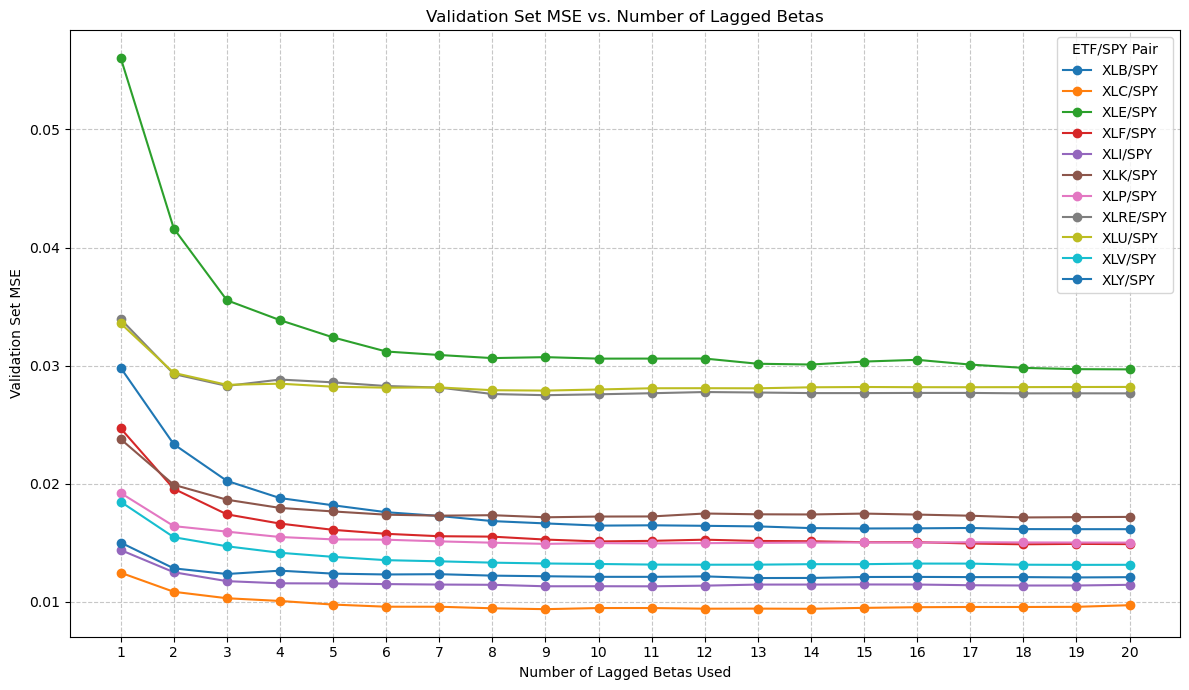

In [46]:
# Create the line plot
plt.figure(figsize=(12, 7))
for ticker in mses_by_lag_df.columns:
    plt.plot(mses_by_lag_df.index, mses_by_lag_df[ticker], marker='o', linewidth=1.5, label=f"{ticker}/SPY")

# Add labels, title, legend, and grid
plt.xlabel("Number of Lagged Betas Used")
plt.ylabel("Validation Set MSE")
plt.title("Validation Set MSE vs. Number of Lagged Betas")
plt.xticks(range(1, 21))
plt.grid(True, alpha=0.7, linestyle='--')
plt.legend(title="ETF/SPY Pair")
plt.tight_layout()
plt.savefig('Images/1IndividualModelsAllLags.png', dpi=300, bbox_inches='tight')
plt.show()

It looks like for each ETF/SPY pair, the performance improves as the number of lagged Betas increases to somewhere between 7 and 10, and then flattens out or worsens after that.

#### 4.4.3 Models Using Data Combined Across All ETF/SPY Pairs

The fact that all the ETF/SPY pairs exhibit the same pattern of performance against the number of lagged Betas suggests that perhaps a single model can be trained on all of the data and produce better performance on each pair than the models that see only the data for that pair. So next, we will combine the data across all of the ETF/SPY pairs and train a single set of models (using 1 to 20 lagged Betas) on the full set of data.

In [47]:
# Combine the ETF/SPY data across all 11 tickers into one training set, one development set, and one test set
X_train_all = pd.concat([X_train_dfs[ticker] for ticker in X_train_dfs], axis=0)
X_dev_all   = pd.concat([X_dev_dfs[ticker]   for ticker in X_dev_dfs],   axis=0)
X_test_all  = pd.concat([X_test_dfs[ticker]  for ticker in X_test_dfs],  axis=0)

y_train_all = pd.concat([y_train_series[ticker] for ticker in y_train_series], axis=0)
y_dev_all   = pd.concat([y_dev_series[ticker]   for ticker in y_dev_series],   axis=0)
y_test_all  = pd.concat([y_test_series[ticker]  for ticker in y_test_series],  axis=0)

# Loop over each lag from 1 to 20
print("Evaluating 20 combined models ...")
combined_models_by_lag = {}
combined_mses_by_lag   = {}
for n_lags in range(1, 21):

    # Select the last n_lags features
    cols = X_train_all.columns[-n_lags:]
    X_train_subset = X_train_all[cols]
    X_dev_subset   = X_dev_all[cols]

    # Create and fit the model
    model = LinearRegression().fit(X_train_subset, y_train_all)

    # Store the fitted model
    combined_models_by_lag[n_lags] = model

    # Calculate and store the validation set MSE
    combined_mses_by_lag[n_lags] = mean_squared_error(y_dev_all, model.predict(X_dev_subset))

print("Done")

# Create a Series from the MSEs for plotting and display
combined_mses_series = pd.Series(combined_mses_by_lag, name="validation_mse")

Evaluating 20 combined models ...
Done


Let's look at the resulting validation set MSEs:

In [48]:
combined_mses_series

1     0.023353
2     0.019258
3     0.018050
4     0.017860
5     0.017635
6     0.017406
7     0.017354
8     0.017204
9     0.017147
10    0.017179
11    0.017184
12    0.017186
13    0.017199
14    0.017225
15    0.017224
16    0.017210
17    0.017182
18    0.017145
19    0.017150
20    0.017178
Name: validation_mse, dtype: float64

And now let's plot them:

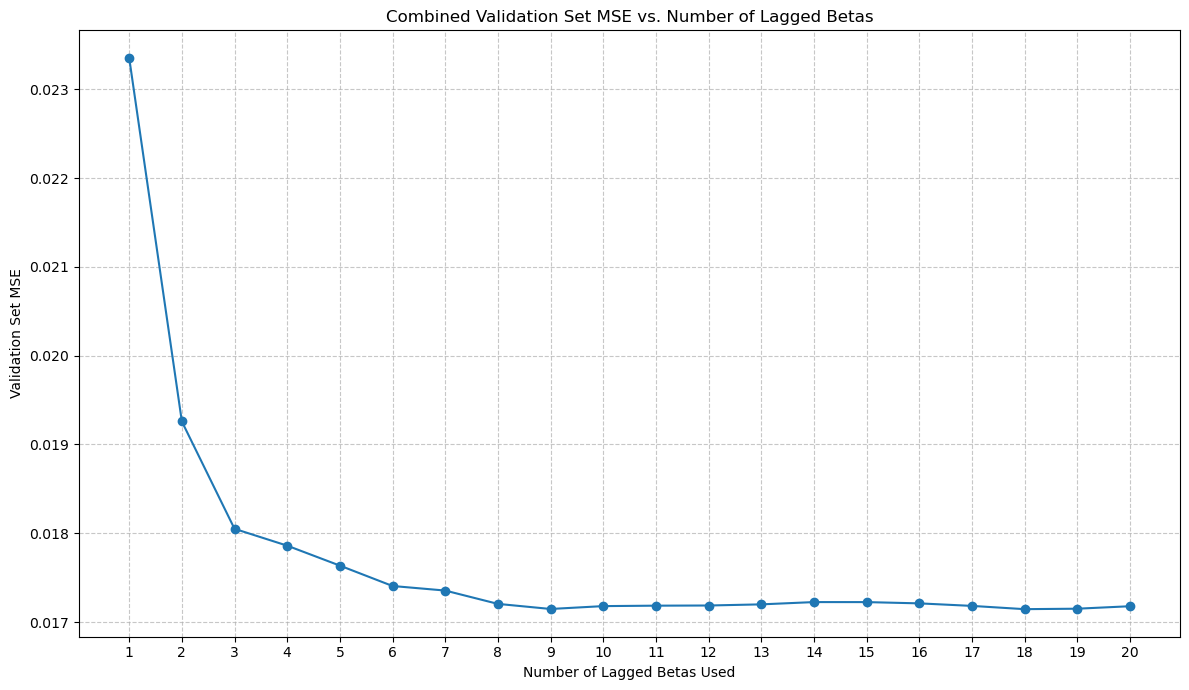

In [49]:
# Create the line plot
plt.figure(figsize=(12, 7))
plt.plot(combined_mses_series.index, combined_mses_series.values, marker='o', linewidth=1.5)

# Add labels, title, and grid
plt.xlabel("Number of Lagged Betas Used")
plt.ylabel("Validation Set MSE")
plt.title("Combined Validation Set MSE vs. Number of Lagged Betas")
plt.xticks(range(1, 21))
plt.grid(True, alpha=0.7, linestyle='--')
plt.tight_layout()
plt.savefig('Images/2CombinedModelAllLags.png', dpi=300, bbox_inches='tight')
plt.show()

The combined model with 9 lagged Betas appears to perform best on the validation set (discounting the models at the far right of the curve that appear to exhibit random fluctuations), with a validation set MSE of **0.017147**

Let's take a look at the coefficients of this model:

Combined model intercept and coefficients for each of the 9 previous days:
Intercept: 0.03272271653564052
Day  -9:  0.0555
Day  -8:  0.0450
Day  -7:  0.0324
Day  -6:  0.0585
Day  -5:  0.0626
Day  -4:  0.0804
Day  -3:  0.1018
Day  -2:  0.1641
Day  -1:  0.3631


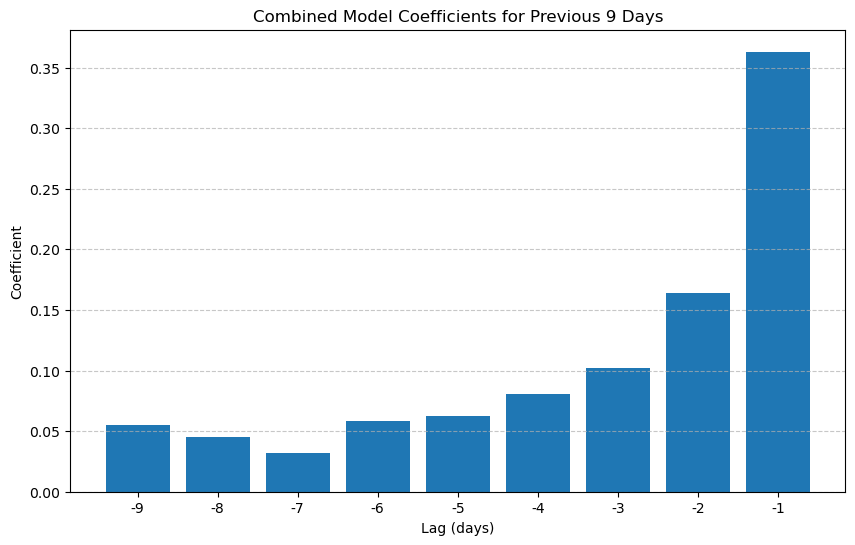

In [50]:
# Get the intercept and the coefficients for the combined model that uses 9 lagged Betas
n_lags = 9
intercept    = combined_models_by_lag[n_lags].intercept_
coefficients = combined_models_by_lag[n_lags].coef_

# Print the intercept and the coefficients
print(f"Combined model intercept and coefficients for each of the {n_lags} previous days:")
print(f"Intercept: {intercept}")
for i, coef in enumerate(coefficients):
    day = -(n_lags - i)
    print(f"Day {day:>3}: {coef: .4f}")

# Plot the coefficients
plt.figure(figsize=(10, 6))
x = range(1, n_lags+1)
plt.bar(x, coefficients)
plt.xlabel('Lag (days)')
plt.ylabel('Coefficient')
plt.title(f'Combined Model Coefficients for Previous {n_lags} Days')
plt.xticks(x, range(-n_lags, 0))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('Images/3CombinedModelCoefficients.png', dpi=300, bbox_inches='tight')
plt.show()

Again, it's clear that the model is calculating a weighted average of the Betas on recent days, with greater weights given to more recent days. I'm not sure what to make of the fact that the weights start going back up after 7 lags, but it could just be random noise.

#### 4.4.4 Performance of 9-Lag Combined Model on Each ETF/SPY Pair

Now we will answer the question of whether the combined model, which gets to see the training data for all ETF/SPY pairs, does better that the eleven separate models trained only on the data for each pair. First, we calculate the performance of this model on each ETF/SPY pair, using the version that looks at 9 lagged Betas:

In [51]:
# For each ETF/SPY pair, calculate the validation set MSE for the combined model that uses 9 lagged Betas
print("Validation set MSEs for combined model that uses 9 lagged Betas:")
combined_9_lag_model = combined_models_by_lag[9]
combined_9_lag_mses  = {}
for ticker in X_dev_dfs:

    # Calculate the performance of the 9 lag combined model on the validation set
    cols = X_dev_dfs[ticker].columns[-9:]
    X_dev_subset = X_dev_dfs[ticker][cols]
    combined_9_lag_mses[ticker] = mean_squared_error(y_dev_series[ticker], combined_9_lag_model.predict(X_dev_subset))
    print(f"{ticker:<4}: {combined_9_lag_mses[ticker]:.6f}")

Validation set MSEs for combined model that uses 9 lagged Betas:
XLB : 0.014048
XLC : 0.009211
XLE : 0.028068
XLF : 0.013679
XLI : 0.010994
XLK : 0.016658
XLP : 0.014876
XLRE: 0.027849
XLU : 0.028182
XLV : 0.013044
XLY : 0.012008


Now we want to compare these performances with the optimal performances for the individual models, selecting the optimal number of lags separately for each pair. We need to start by finding the minimum MSEs in each column of the DataFrame we calculated previously that contains the individual results for all 20 possible lags:

In [52]:
# For each ETF/SPY pair, find the optimal validation set MSE from the individual models for 1 through 20 lags
print("Optimal validation set MSEs for individual ETF/SPY models:")
optimal_mses = {}
optimal_lags = {}
for ticker in mses_by_lag_df.columns:
    optimal_lags[ticker] = mses_by_lag_df[ticker].idxmin()
    optimal_mses[ticker] = mses_by_lag_df[ticker].min()
    print(f"{ticker:<4}: {optimal_mses[ticker]:.6f}  (lags = {optimal_lags[ticker]:>2})")

Optimal validation set MSEs for individual ETF/SPY models:
XLB : 0.016152  (lags = 20)
XLC : 0.009382  (lags =  9)
XLE : 0.029683  (lags = 20)
XLF : 0.014874  (lags = 18)
XLI : 0.011316  (lags = 11)
XLK : 0.017147  (lags = 18)
XLP : 0.014908  (lags =  9)
XLRE: 0.027498  (lags =  9)
XLU : 0.027887  (lags =  9)
XLV : 0.013131  (lags = 19)
XLY : 0.012017  (lags = 13)


Now we can compare the results of the Baseline model, the Individual Optimal models, and the Combined 9-Lag model:

In [53]:
# Create a DataFrame comparing the three model types
results_df = pd.DataFrame([mses_dummy_last, optimal_mses, combined_9_lag_mses],
    index=["Baseline MSE", "Individual Optimal MSE", "Combined 9-Lag MSE"]
)
results_df

,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Baseline MSE,0.020568,0.013305,0.041453,0.017483,0.015993,0.021636,0.020552,0.039541,0.040109,0.017832,0.017452
Individual Optimal MSE,0.016152,0.009382,0.029683,0.014874,0.011316,0.017147,0.014908,0.027498,0.027887,0.013131,0.012017
Combined 9-Lag MSE,0.014048,0.009211,0.028068,0.013679,0.010994,0.016658,0.014876,0.027849,0.028182,0.013044,0.012008


With two minor exceptions (XLRE and XLU), the Combined 9-Lag model outperforms the Individual Optimal models, and both are clearly better than the Baseline model.

Let's visualize these results in a bar plot:

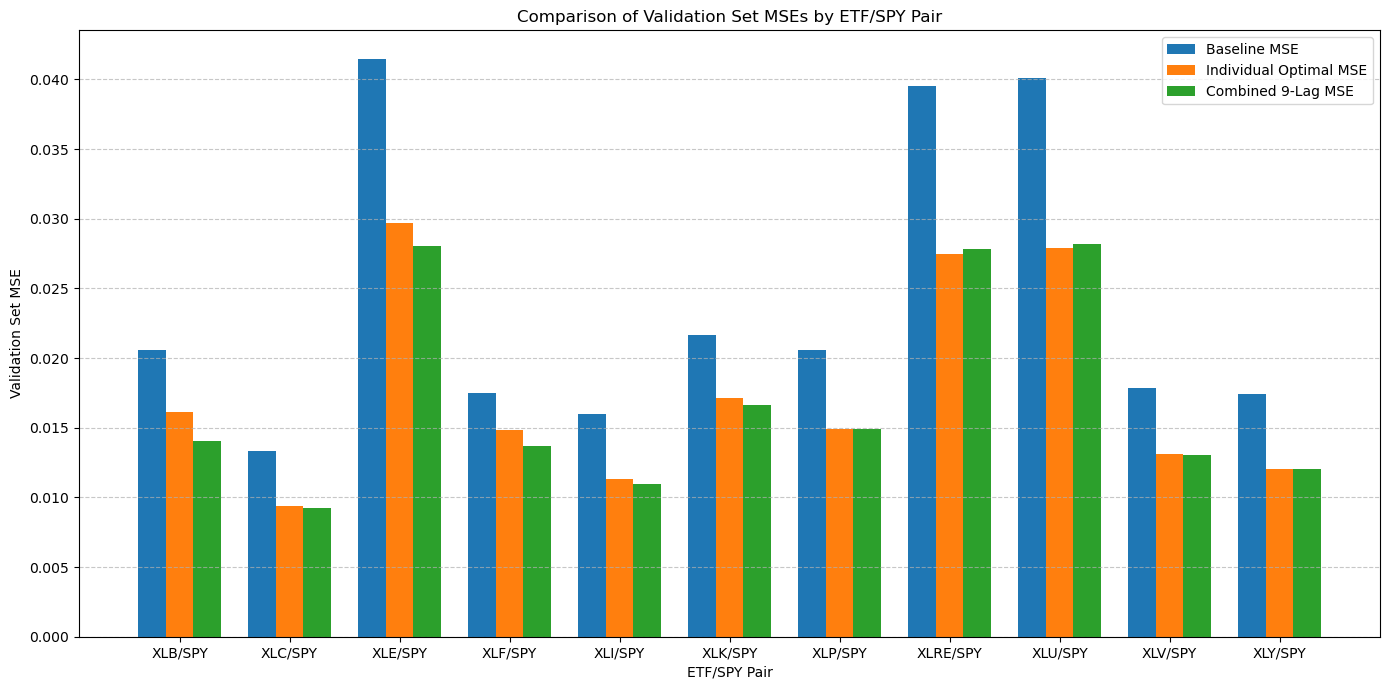

In [54]:
# Set up to draw a bar plot
plot_df = results_df.T
x = np.arange(len(plot_df.index))
width = 0.25

# Draw the bar plot
plt.figure(figsize=(14, 7))
plt.bar(x - width, plot_df["Baseline MSE"],           width=width, label="Baseline MSE")
plt.bar(x,         plot_df["Individual Optimal MSE"], width=width, label="Individual Optimal MSE")
plt.bar(x + width, plot_df["Combined 9-Lag MSE"],     width=width, label="Combined 9-Lag MSE")

# Add labels, title, and grid
plt.xlabel("ETF/SPY Pair")
plt.ylabel("Validation Set MSE")
plt.title("Comparison of Validation Set MSEs by ETF/SPY Pair")
plt.xticks(x, [f"{ticker}/SPY" for ticker in plot_df.index])
plt.grid(True, axis="y", alpha=0.7, linestyle="--")
plt.legend()
plt.tight_layout()
plt.savefig('Images/4ComparisonOfAllModels.png', dpi=300, bbox_inches='tight')
plt.show()

#### 4.4.5 Lasso Regularization for Selecting Optimal Features

Before wrapping up, let's see if we can use Lasso regularation in a grid search with different alpha values to do better a better job at selecting the input features (lagged Betas) to use, and come up with an improved MSE score on the validation set. The grid search is complicated by the fact that we can't use K-fold validation, as mentioned above, so we'll need to implement a pre-defined split for the validation:

In [55]:
# Combine the existing training and development sets before creating a fixed split for validation
X_train_dev_all = pd.concat([X_train_all, X_dev_all], axis=0)
y_train_dev_all = pd.concat([y_train_all, y_dev_all], axis=0)

# Define the fixed split where training rows are -1 and validation rows are 0
test_fold = np.concatenate([np.full(len(X_train_all), -1), np.zeros(len(X_dev_all), dtype=int)])
ps = PredefinedSplit(test_fold=test_fold)

# Define the model and the alpha grid
pipe = make_pipeline(
    StandardScaler(),
    Lasso(max_iter=100000, random_state=0)
)
alpha_grid = np.logspace(-5, 1, 50)

# Define the grid search
grid = GridSearchCV(
    estimator=pipe,
    param_grid={"lasso__alpha": alpha_grid},
    scoring="neg_mean_squared_error",
    cv=ps,
    refit=False
)

# Run the grid search
print("Performing the grid search ...")
grid.fit(X_train_dev_all, y_train_dev_all)
print("Done")

# Build the results table
results_df = pd.DataFrame({
    "alpha": grid.cv_results_["param_lasso__alpha"].astype(float),
    "validation_mse": -grid.cv_results_["mean_test_score"]
})

# Add the number of non-zero features for each alpha
nonzero_counts = []
for alpha in results_df["alpha"]:
    model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=alpha, max_iter=100000, random_state=0)
    )
    model.fit(X_train_all, y_train_all)
    nonzero_counts.append(np.count_nonzero(model.named_steps["lasso"].coef_))
results_df["nonzero_features"] = nonzero_counts

# Sort by alpha and display the results
results_df = results_df.sort_values("alpha").reset_index(drop=True)
results_df

Performing the grid search ...
Done


,alpha,validation_mse,nonzero_features
0,0.000010,0.017178,20
1,0.000013,0.017178,20
2,0.000018,0.017178,20
3,0.000023,0.017178,20
4,0.000031,0.017178,20
5,0.000041,0.017178,20
6,0.000054,0.017178,20
7,0.000072,0.017178,20
8,0.000095,0.017178,19
9,0.000126,0.017178,19


A quick review of these results shows that regularization did not produce an improvement in validation set MSE over the Combined 9-Lag model, which had  validation set MSE of **0.017147**. Therefore the Combined 9-Lag model remains the best model produced in this study.

### 4.5 Performance on the Test Set

Finally, it's time to look at the performance of the best model, the Combined 9-Lag model, on the holdout test set:

In [56]:
# Evaluate the Combined 9-Lag model on the combined test set
combined_9_lag_test_mse = mean_squared_error(y_test_all, combined_models_by_lag[9].predict(X_test_all[X_test_all.columns[-9:]]))
print(f"Test set MSE for Combined 9-Lag model: {combined_9_lag_test_mse:.6f}")

Test set MSE for Combined 9-Lag model: 0.018898


This result is only slightly higher than the validation set MSE of 0.017147, so it doesn't appear that overfitting due to model selection has occurred.

## 5 Conclusion

The primary conclusion from this study is that by using a linear regression model with 9 previous day's Betas as inputs, it is possible to predict the daily Betas of sector ETFs against SPY more accurately than by just looking at the previous day's Beta, or by looking at the average Beta over a long historical time frame. Furthermore, using a single model that is trained on data combined across all the sector ETFs is better than training individual models separately for each ETF/SPY pair, due to the increased amount of training data available.

## 6 Next Steps

The next steps that I recommend for work in this area are as follows:
* **Model Improvements:** First, conduct additional research to improve the prediction model:
	* Incorporate additional data into the feature set, such as market volatility and interest rate data
	* Replace linear regression models with neural networks to capture non-linear relationships between the features
	* Try using recurrent neural networks (RNNs) to take advantage of the time series aspect of the problem
* **Deployment:** Then once an enhanced model has been produced, deploy the model by integrating the prediction algorithm into traders' workflow, so that they can adjust their hedge ratios for pair trades on a daily basis.